In [1]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/adaptive_al /home/dhuseljic/mlflow/

receiving incremental file list

sent 27 bytes  received 507 bytes  1,068.00 bytes/sec
total size is 793,542,656  speedup is 1,486,034.94


In [2]:
import os
import mlflow
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from collections import defaultdict
from pathlib import Path
from cycler import cycler
import time
import datetime

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (3, 2),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,
    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    # Save figure settings
    "savefig.dpi": 300,
    # "axes.spines.top": False,
    # "axes.spines.right": False,
}

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#65406B", "#DAB66C", "#A2D5C6", "#E699B3"])

plot_dir = Path('/home/dhuseljic/paper_plots/adaptive_al/')
os.makedirs(plot_dir, exist_ok=True)

uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/refine.db'
baselines_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db'

client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

2025/11/20 08:49:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/20 08:49:52 INFO mlflow.store.db.utils: Updating database tables
2025-11-20 08:49:52 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-20 08:49:52 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-20 08:49:52 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-20 08:49:52 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


[('main_results_v1', '23-10-25'), ('Default', '23-10-25')]

In [7]:
def get_runs(uri, exp_name, query_list=[""], after=None, before=None, **kwargs):
    client = mlflow.tracking.MlflowClient(tracking_uri=uri)
    experiment_id = client.get_experiment_by_name(exp_name).experiment_id
    max_res = kwargs.get('max_results', 10000)
    filter_string = ' and '.join(query_list) if len(query_list) > 1 else query_list[0]
    runs = client.search_runs(experiment_ids=experiment_id, filter_string=filter_string, max_results=max_res)


    if after is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) > after]
    if before is not None:
        runs = [run for run in runs if (run.info.end_time / 1000) < before]

    # runs = filter_duplicate_seeds(runs)
    # runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))

    print(f'Got {len(runs)} runs for experiments {exp_name} with query {query_list}.')
    return runs

def filter_duplicate_seeds(runs):
    # remove runs with duplicate random seeds
    seen_seeds = set()
    unique_runs = []
    for run in runs:
        seed = run.data.params['random_seed']
        if seed not in seen_seeds:
            unique_runs.append(run)
            seen_seeds.add(seed)
    return unique_runs

def get_metric(run, uri, metric):
    client = mlflow.tracking.MlflowClient(uri)
    m_values = [m.value for m in client.get_metric_history(run.info.run_id, metric)]
    return m_values

def get_avg_lc(runs, uri, metric='accuracy', return_std=False):
    lcs = []
    for run in runs:
        m_values = get_metric(run, uri, metric)
        if len(m_values) == 0:
            print(f'No metric values found for run {run.info.run_id}.')
        if len(m_values) != 21:
            continue
        lcs.append(m_values)
    avg_lc = np.mean(lcs, axis=0)
    if return_std:
        std_lc = np.std(lcs, axis=0)
        return avg_lc, std_lc 
    return avg_lc
    
def get_axis_from_run(run):
    acq_size = eval(run.data.params['dataset.acq_size'])
    num_acq = eval(run.data.params['dataset.num_acq'])
    budget = acq_size + num_acq*acq_size
    axis = np.arange(acq_size, budget+1, acq_size)
    return axis

In [8]:
baselines_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db'
dataset = ['cifar10', 'dopanim', 'snacks', 'cifar100', 'food101', 'tiny_imagenet', 'imagenet'][6]
backbone = ['dinov2', 'clip', 'dinov3'][2]
exp_name = 'baselines_v1'
init_query_list = [f"parameter.dataset.name = '{dataset}'", f"parameter.model.backbone = '{backbone}'"]
# init_query_list += ["parameter.optimizer.name = 'SGD'", "parameter.optimizer.lr = '0.01'", "parameter.optimizer.weight_decay = '0.0005'"]
baseline_runs = {
    'random': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'random'"]),
    'margin': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'margin'"]),
    # 'badge': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'badge'"]),
    'bait': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'bait'"]),
    'typiclust': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'typiclust'"]),
    # 'max_herding': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'max_herding'"]),
    'unc_herding': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'uncertainty_herding'"]),
    'alfamix': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'alfamix'"]),
    'dropquery': get_runs(baselines_uri, exp_name, init_query_list + ["parameter.al.strategy = 'dropquery'"]),
    # 'select_al': get_runs(baselines_uri, exp_name, [f"parameter.dataset.name = '{dataset}'", "parameter.al.strategy = 'select_al'"]),
    # 'tcm': get_runs(baselines_uri, exp_name, [f"parameter.dataset.name = '{dataset}'", "parameter.al.strategy = 'tcm'"]),
}
tmp_run = baseline_runs['random'][0]
try:
    acq_size = eval(tmp_run.data.params['al.acq_size'])
    num_acq = eval(tmp_run.data.params['al.num_acq'])
except:
    acq_size = eval(tmp_run.data.params['dataset.acq_size'])
    num_acq = eval(tmp_run.data.params['dataset.num_acq'])
budget = acq_size + num_acq*acq_size
axis = np.arange(acq_size, budget+1, acq_size)

Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'imagenet'", "parameter.model.backbone = 'dinov3'", "parameter.al.strategy = 'random'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'imagenet'", "parameter.model.backbone = 'dinov3'", "parameter.al.strategy = 'margin'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'imagenet'", "parameter.model.backbone = 'dinov3'", "parameter.al.strategy = 'bait'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'imagenet'", "parameter.model.backbone = 'dinov3'", "parameter.al.strategy = 'typiclust'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'imagenet'", "parameter.model.backbone = 'dinov3'", "parameter.al.strategy = 'uncertainty_herding'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'imagenet'", "parameter.model.backbone = 'dinov3'", "parameter.al.s

## Main Comparisons

In [12]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/refine_new.db'
old_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/refine_old.db'
refine_runs = {
    'refine': get_runs(uri, 'main_results_v1', init_query_list + ["parameter.al.strategy = 'refine'"], after=time.time() - 60 * 60 *24),
}
# refine_runs["refine"][0].data.params

Got 6 runs for experiments main_results_v1 with query ["parameter.dataset.name = 'imagenet'", "parameter.model.backbone = 'dinov3'", "parameter.al.strategy = 'refine'"].


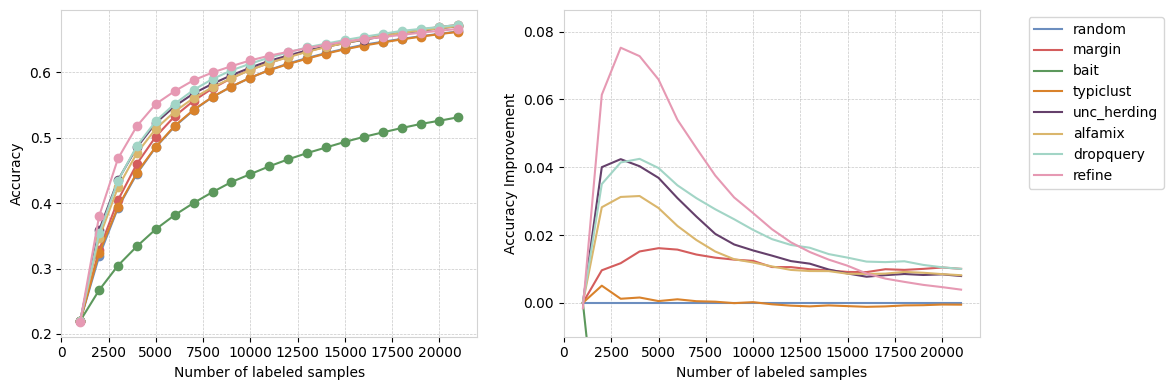

,AUC
bait,0.430476
random,0.555711
typiclust,0.555785
margin,0.566657
alfamix,0.569979
unc_herding,0.573530
dropquery,0.576953
refine,0.583456


In [13]:
# old_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/refine_old.db'
# avg_lc_old = get_avg_lc(get_runs(old_uri, 'main_results_v2', init_query_list + ["parameter.al.strategy = 'refine'"]), old_uri)

plt.figure(figsize=(5*2, 4))
plt.subplot(121)
for key in baseline_runs:
    avg_lc = get_avg_lc(baseline_runs[key], baselines_uri)
    plt.plot(axis, avg_lc, '-o', label=key)
for key, runs in refine_runs.items():
    avg_lc_aal = get_avg_lc(runs, uri)
    plt.plot(axis, avg_lc_aal, '-o', label=key)
# plt.plot(axis, avg_lc_old, '-o', label='old refine')
plt.xlabel('Number of labeled samples')
plt.ylabel('Accuracy')

aucs = {}
plt.subplot(122)
for key in baseline_runs:
    avg_lc = get_avg_lc(baseline_runs[key], baselines_uri)
    avg_lc_random = get_avg_lc(baseline_runs['random'], baselines_uri)
    aucs[key] = np.mean(avg_lc)
    plt.plot(axis, avg_lc - avg_lc_random, label=key)
for key, runs in refine_runs.items():
    avg_lc_aal = get_avg_lc(runs, uri)
    aucs[key] = np.mean(avg_lc_aal)
    avg_lc_random = get_avg_lc(baseline_runs['random'], baselines_uri)
    plt.plot(axis, avg_lc_aal - avg_lc_random, label=key)
# plt.plot(axis, avg_lc_old- avg_lc_random, label='old refine')
plt.xlabel('Number of labeled samples')
plt.ylabel('Accuracy Improvement')
plt.tight_layout()
plt.legend(loc=2, bbox_to_anchor=(1.1, 1))
plt.ylim(bottom=-0.01)
plt.show()
df = pd.DataFrame(aucs, index=['AUC']).T
df.sort_values('AUC')

## Main Results

In [82]:
baselines_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db'
exp_name = 'baselines_v1'
all_bl_runs = get_runs(baselines_uri, exp_name=exp_name)

Got 1863 runs for experiments baselines_v1 with query [''].


In [15]:
all_models = np.unique([run.data.params['model.backbone'] for run in all_bl_runs]).tolist()
all_datasets = np.unique([run.data.params['dataset.name'] for run in all_bl_runs]).tolist()
all_strats = np.unique([run.data.params['al.strategy'] for run in all_bl_runs]).tolist()

# all_models.remove('dinov3')
# all_datasets.remove('cifar10')
all_datasets.remove('imagenet')

all_lcs = defaultdict(dict)
axis_ds = {}

for model_name in all_models:
    runs_model = [run for run in all_bl_runs if run.data.params['model.backbone'] == model_name]
    for dataset_name in all_datasets:
        runs_backbone = [run for run in runs_model if run.data.params['dataset.name'] == dataset_name]
        axis_ds[dataset_name] = get_axis_from_run(runs_backbone[0])
        lcs_strats = {}
        for strat_name in all_strats:
            runs_strat = [run for run in runs_backbone if run.data.params['al.strategy'] == strat_name]
            sorted_runs = sorted(runs_strat, key=lambda run: int(run.data.params['random_seed']))
            filtered_runs = filter_duplicate_seeds(sorted_runs)
            print(model_name, dataset_name, strat_name, len(filtered_runs))

            # print(f'Processing {model_name} - {dataset_name} - {strat_name}: {len(runs_strat)} runs.')
            lcs = [get_metric(run, baselines_uri, 'accuracy') for run in filtered_runs]
            # print([len(lc) for lc in lcs])
            lcs = np.array(lcs)
            lcs_strats[strat_name] = lcs


        all_lcs[model_name][dataset_name] = lcs_strats


clip cifar10 alfamix 10
clip cifar10 badge 10
clip cifar10 bait 10
clip cifar10 dropquery 10
clip cifar10 margin 10
clip cifar10 max_herding 10
clip cifar10 random 10
clip cifar10 typiclust 10
clip cifar10 uncertainty_herding 10
clip cifar100 alfamix 10
clip cifar100 badge 10
clip cifar100 bait 10
clip cifar100 dropquery 10
clip cifar100 margin 10
clip cifar100 max_herding 10
clip cifar100 random 10
clip cifar100 typiclust 10
clip cifar100 uncertainty_herding 10
clip dopanim alfamix 10
clip dopanim badge 10
clip dopanim bait 10
clip dopanim dropquery 10
clip dopanim margin 10
clip dopanim max_herding 10
clip dopanim random 10
clip dopanim typiclust 10
clip dopanim uncertainty_herding 10
clip food101 alfamix 10
clip food101 badge 10
clip food101 bait 10
clip food101 dropquery 10
clip food101 margin 10
clip food101 max_herding 10
clip food101 random 10
clip food101 typiclust 10
clip food101 uncertainty_herding 10
clip snacks alfamix 10
clip snacks badge 10
clip snacks bait 10
clip snacks

In [16]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/refine_new.db'
# all_refine_runs = get_runs(uri, 'refine_v1' , ["parameter.al.strategy = 'refine'"])
all_refine_runs = get_runs(uri, 'main_results_v1' , ["parameter.al.strategy = 'refine'"])

# all_models = np.unique([run.data.params['model.backbone'] for run in all_refine_runs]).tolist()
# all_datasets = np.unique([run.data.params['dataset.name'] for run in all_refine_runs]).tolist()
# all_datasets.remove('cifar10')
#all_datasets.remove('imagenet')

all_pool_sizes = defaultdict(dict)

for model_name in all_models:
    runs_model = [run for run in all_refine_runs if run.data.params['model.backbone'] == model_name]
    for dataset_name in all_datasets:
        runs_backbone = [run for run in runs_model if run.data.params['dataset.name'] == dataset_name]
        print(model_name, dataset_name, len(runs_backbone))

        runs = runs_backbone
        runs = sorted(runs, key=lambda run: int(run.data.params['random_seed']))
        lcs = [get_metric(run, uri, 'accuracy') for run in runs]
        print([len(lc) for lc in lcs])
        lcs = np.array(lcs)

        all_lcs[model_name][dataset_name]['refine'] = lcs

        pool_sizes = [get_metric(run, uri, 'pool_4') for run in runs]
        all_pool_sizes[model_name][dataset_name] = np.mean(pool_sizes, axis=0)

Got 190 runs for experiments main_results_v1 with query ["parameter.al.strategy = 'refine'"].
clip cifar10 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
clip cifar100 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
clip dopanim 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
clip food101 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
clip snacks 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
clip tiny_imagenet 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov2 cifar10 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov2 cifar100 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov2 dopanim 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov2 food101 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov2 snacks 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov2 tiny_imagenet 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov3 cifar10 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov3 cifar100 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov3 dopanim 10
[21, 21, 21, 21, 21, 21, 21, 21, 21, 21]
dinov3 food101 10
[2

In [187]:
from scipy import stats
from matplotlib import patheffects

def create_pairwise_comparison_matrix(lc_dict, alpha=0.05):
    strategy_names = list(lc_dict.keys())
    n_strategies = len(strategy_names)
    
    # Initialize comparison matrix
    matrix = np.zeros((n_strategies, n_strategies))
    
    # Get number of cycles from first strategy
    num_seeds, num_cycles = list(lc_dict.values())[0].shape
    
    # Compare each pair of lc_dict
    for i, strat_i in enumerate(strategy_names):
        for j, strat_j in enumerate(strategy_names):
            if i == j:
                continue
                
            # Paired t-test and check if i significantly outperforms j
            # t_stat, p_value = stats.ttest_rel(acc_i, acc_j)
            # if p_value < alpha and np.mean(acc_i) > np.mean(acc_j):
            #     wins += 1
            
            wins=0
            curves_i = lc_dict[strat_i]
            curves_j = lc_dict[strat_j]

            auc_i = np.mean(curves_i, axis=1)
            auc_j = np.mean(curves_j, axis=1)
            for seed in range(num_seeds):
                if auc_i[seed] > auc_j[seed]:
                    wins+=1
            matrix[i, j] = wins / len(auc_i)
            
            # wins = 0
            # for seed in range(num_seeds):
            #     for cycle in range(1, num_cycles): # first cycle is identical due to same init set
            #         acc_i = curves_i[seed, cycle]
            #         acc_j = curves_j[seed, cycle]

            #         if acc_i > acc_j:
            #             wins += 1
            # matrix[i, j] = wins / (num_cycles*num_seeds)
    
    return matrix, strategy_names

all_mats = []
for model in all_models:
    for dataset in all_datasets:
        mat, names = create_pairwise_comparison_matrix(all_lcs[model][dataset])
        all_mats.append(mat)
avg_mat = np.mean(all_mats, axis=0)

# strat_order = ['random', 'margin', 'badge', 'bait', 'typiclust', 'alfamix', 'dropquery', 'max_herding', 'uncertainty_herding']
strat_order = ['random', 'margin', 'badge', 'bait', 'typiclust', 'alfamix', 'dropquery', 'max_herding', 'uncertainty_herding', 'refine']
indices_order = [names.index(s) for s in strat_order]

avg_mat = avg_mat[np.ix_(indices_order, indices_order)]
np.fill_diagonal(avg_mat, 0.5)
# names = ['Random', 'Margin', 'BADGE', 'BAIT', 'TypiClust', 'AlfaMix', 'DropQuery', 'MaxHerding', 'UHerding']
# names = ['Random', 'Margin', 'BADGE', 'BAIT', 'TypiClust', 'AlfaMix', 'DropQuery', 'MaxHerding', 'UHerding', 'Refine']
names = [names[i] for i in indices_order]

plt.figure(figsize=(8, 6))
plt.grid()
plt.imshow(avg_mat, cmap='RdYlGn')
for i in range(len(names)):
    for j in range(len(names)):
        if i == j:continue
        text = plt.text(j, i, f'{avg_mat[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')
        # text.set_path_effects([patheffects.Stroke(linewidth=1.2, foreground='white'), patheffects.Normal()])

plt.xticks(range(len(mat)), names, rotation=30, ha='right')
plt.yticks(range(len(mat)), names)
plt.savefig(plot_dir / f'avg_pairwise_comparison_matrix.pdf', bbox_inches='tight')
plt.show()

ValueError: 'margin' is not in list

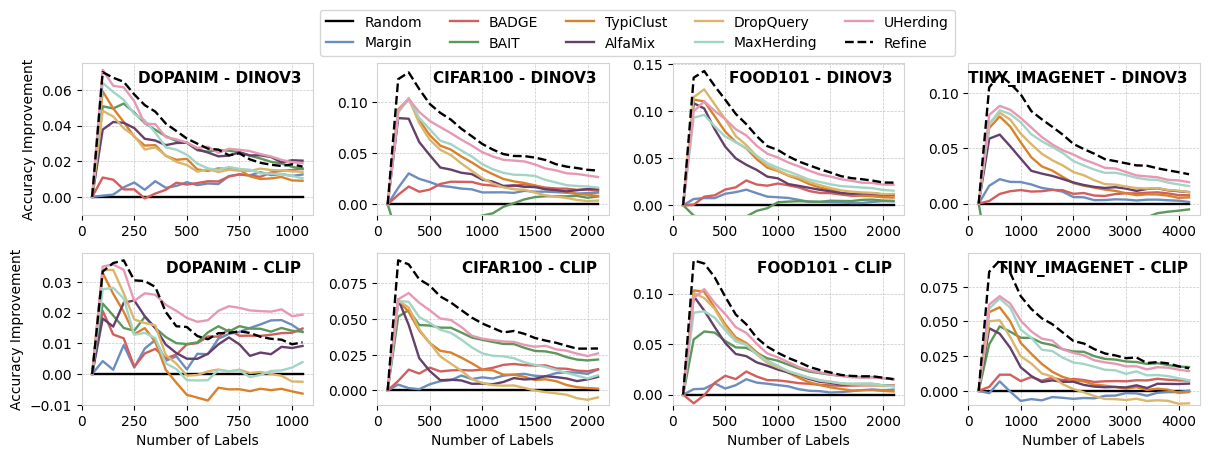

In [ ]:
plot_kwargs = {
    'refine':               dict(lw=1.7, ls='--', color='black', label='Refine'),
    'random':               dict(lw=1.7, ls='-', color='black', label='Random'),
    'margin':               dict(lw=1.7, ls='-', color='C0', label='Margin'),
    'badge':                dict(lw=1.7, ls='-', color='C1', label='BADGE'),
    'bait':                 dict(lw=1.7, ls='-', color='C2', label='BAIT'),
    'typiclust':            dict(lw=1.7, ls='-', color='C3', label='TypiClust'),
    'alfamix':              dict(lw=1.7, ls='-', color='C4', label='AlfaMix'),
    'dropquery':            dict(lw=1.7, ls='-', color='C5', label='DropQuery'),
    'max_herding':          dict(lw=1.7, ls='-', color='C6', label='MaxHerding'),
    'uncertainty_herding':  dict(lw=1.7, ls='-', color='C7', label='UHerding'),
}

datasets_backbones = [
    ('dopanim', 'dinov3'), ('cifar100', 'dinov3'), ('food101', 'dinov3'), ('tiny_imagenet', 'dinov3'), 
    ('dopanim', 'clip'), ('cifar100', 'clip'), ('food101', 'clip'),  ('tiny_imagenet', 'clip'),
]

strats = ['random', 'margin', 'badge', 'bait', 'typiclust', 'alfamix', 'dropquery', 'max_herding', 'uncertainty_herding', 'refine']

nrows, ncols = 2, 4
fig, ax = plt.subplots(figsize=(3*ncols, 2*nrows), ncols=ncols, nrows=nrows)
ax = ax.flatten()

absolute = False
for i_ds, (ds, backbone) in enumerate(datasets_backbones):
    plt.sca(ax[i_ds])
    avg_lc_random = np.mean(all_lcs[backbone][ds]['random'], 0)
    axis = axis_ds[ds]
    for strat in strats:
        avg_lc = np.mean(all_lcs[backbone][ds][strat], 0)
        target = avg_lc 
        target -= 0 if absolute else avg_lc_random 
        plt.plot(axis, target, **plot_kwargs[strat])

    text_y_pos = 0.15 if absolute else 0.95
    s = f"{ds.upper()} - {backbone.upper()}"
    ax[i_ds].text(0.95, text_y_pos, s, 
                  transform=ax[i_ds].transAxes,
                  fontsize=11, fontweight='bold',
                  verticalalignment='top',
                  horizontalalignment='right')
    plt.ylim(bottom=-0.01)

plt.tight_layout()
ax[0].legend(bbox_to_anchor=(1, 1.4), loc='upper left', ncol=5)
for a in ax[-4:]:
    a.set_xlabel('Number of Labels')
ax[0].set_ylabel('Accuracy Improvement')
ax[4].set_ylabel('Accuracy Improvement')

plt.savefig(plot_dir / f'main_results_relacc.pdf', bbox_inches='tight')
plt.show()

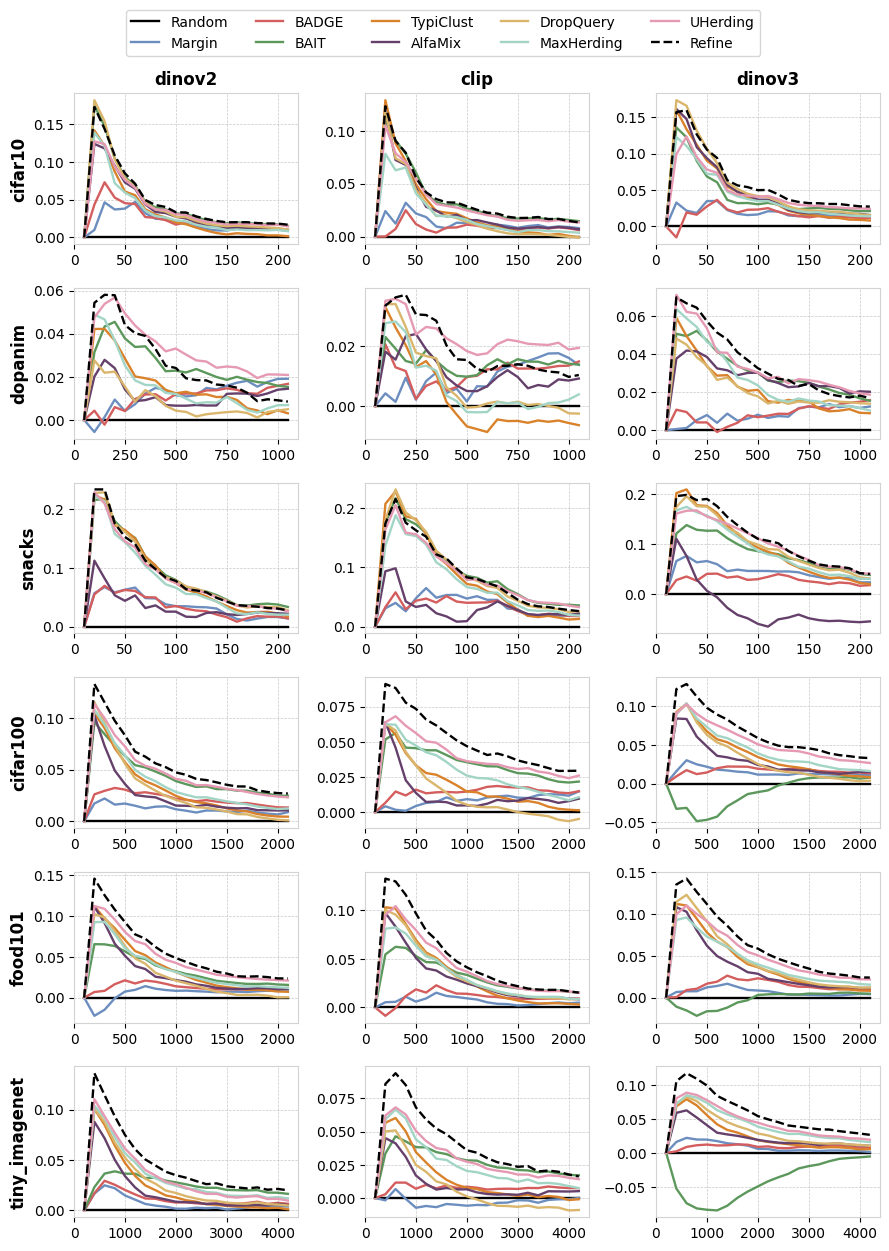

In [22]:
strats = ['random', 'margin', 'badge', 'bait', 'typiclust', 'alfamix', 'dropquery', 'max_herding', 'uncertainty_herding', 'refine']

all_datasets = ['cifar10', 'dopanim', 'snacks', 'cifar100', 'food101', 'tiny_imagenet']
all_models = ['dinov2', 'clip', 'dinov3']
nrows = len(all_datasets)
ncols = len(all_models)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols,2*nrows))

absolute = False
for i, ds in enumerate(all_datasets):
    for j, m in enumerate(all_models):
        plt.sca(axes[i, j])
        avg_lc_random = np.mean(all_lcs[m][ds]['random'], 0)
        axis = axis_ds[ds]

        for strat in strats:
            avg_lc = np.mean(all_lcs[m][ds][strat], 0)
            target = avg_lc 
            target -= 0 if absolute else avg_lc_random 
            plt.plot(axis, target, **plot_kwargs[strat])
        if i == 0:
            axes[i, j].set_title(m, fontsize=12, fontweight='bold')
        if j == 0:
            axes[i, j].set_ylabel(ds, fontsize=12, fontweight='bold')

    
    # text_y_pos = 0.15 if absolute else 0.95
    # ax[i_ds].text(0.95, text_y_pos, s, 
    #               transform=ax[i_ds].transAxes,
    #               fontsize=11, fontweight='bold',
    #               verticalalignment='top',
    #               horizontalalignment='right')
    # plt.ylim(bottom=-0.01)

plt.tight_layout()
axes[0, 0].legend(bbox_to_anchor=(.2, 1.6), loc='upper left', ncol=5)
# for a in ax[-4:]:
#     a.set_xlabel('Number of Labels')
# ax[0].set_ylabel('Accuracy Improvement')
# ax[4].set_ylabel('Accuracy Improvement')
lc_type = {True: 'absolute', False: 'relative'}
plt.savefig(plot_dir / f'main_results_complete_{lc_type[absolute]}.pdf', bbox_inches='tight')

plt.show()

## Ensemble AL Methods

In [173]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines_paul.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
print([(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()])

ensemble_runs = get_runs(uri, exp_name='ensemble-baselines-new')
ensemble_runs = [run for run in runs if len(run.data.params) > 0]

[('ensemble-baselines-new', '01-11-25'), ('ensemble-baselines', '31-10-25'), ('baselines', '30-10-25'), ('Default', '30-10-25')]
Got 942 runs for experiments ensemble-baselines-new with query [''].


In [174]:
all_datasets = np.unique([run.data.params['dataset.name'] for run in ensemble_runs]).tolist()
all_models = np.unique([run.data.params['model.backbone'] for run in ensemble_runs]).tolist()
all_strats = ['select_al', 'tailor2', 'tcm']
#all_strats = np.unique([run.data.params['al.strategy'] for run in runs]).tolist()

all_lcs = {}
axis_ds = {}
for m in all_models:
    runs_model = [run for run in ensemble_runs if run.data.params['model.backbone'] == m]

    lcs_datasets = {}
    for d in all_datasets:
        runs_ds = [run for run in runs_model if run.data.params['dataset.name'] == d]
        axis_ds[d] = get_axis_from_run(runs_ds[0])

        lcs_strats = {}
        for s in all_strats:
            runs_strat = [run for run in runs_ds if run.data.params['al.strategy'] in s]
            runs_strat = [run for run in runs_strat if len(get_metric(run, uri, 'accuracy')) == 21]
            runs_strat = filter_duplicate_seeds(runs_strat)
            runs_strat = sorted(runs_strat, key=lambda run: int(run.data.params['random_seed']))
            print(m, d, s, len(runs_strat))
            # print([run.data.params['random_seed'] for run in runs_strat])
            lcs = [get_metric(run, uri, 'accuracy') for run in runs_strat]
            lcs = np.array(lcs)
            lcs_strats[s] = lcs
        lcs_datasets[d] = lcs_strats
    all_lcs[m] = lcs_datasets

clip cifar10 select_al 10
clip cifar10 tailor2 10
clip cifar10 tcm 10
clip cifar100 select_al 10
clip cifar100 tailor2 10
clip cifar100 tcm 10
clip dopanim select_al 10
clip dopanim tailor2 10
clip dopanim tcm 10
clip food101 select_al 10
clip food101 tailor2 10
clip food101 tcm 10
clip snacks select_al 10
clip snacks tailor2 10
clip snacks tcm 10
clip tiny_imagenet select_al 10
clip tiny_imagenet tailor2 10
clip tiny_imagenet tcm 10
dinov2 cifar10 select_al 10
dinov2 cifar10 tailor2 10
dinov2 cifar10 tcm 10
dinov2 cifar100 select_al 10
dinov2 cifar100 tailor2 10
dinov2 cifar100 tcm 10
dinov2 dopanim select_al 10
dinov2 dopanim tailor2 10
dinov2 dopanim tcm 10
dinov2 food101 select_al 10
dinov2 food101 tailor2 10
dinov2 food101 tcm 10
dinov2 snacks select_al 10
dinov2 snacks tailor2 10
dinov2 snacks tcm 10
dinov2 tiny_imagenet select_al 10
dinov2 tiny_imagenet tailor2 10
dinov2 tiny_imagenet tcm 10
dinov3 cifar10 select_al 10
dinov3 cifar10 tailor2 10
dinov3 cifar10 tcm 10
dinov3 cifar

In [175]:
baselines_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db'
exp_name = 'baselines_v1'
random_runs = get_runs(baselines_uri, exp_name, ["parameter.al.strategy = 'random'"])

for m in all_models:
    runs_model = [run for run in random_runs if run.data.params['model.backbone'] == m]

    lcs_datasets = {}
    for d in all_datasets:
        runs_ds = [run for run in runs_model if run.data.params['dataset.name'] == d]
        runs_ds = filter_duplicate_seeds(runs_ds)
        runs_ds = sorted(runs_ds, key=lambda run: int(run.data.params['random_seed']))
        print(m, d, 'random', len(runs_ds))

        lcs = [get_metric(run, baselines_uri, 'accuracy') for run in runs_ds]
        lcs = np.array(lcs)
        all_lcs[m][d]['random'] = lcs

Got 215 runs for experiments baselines_v1 with query ["parameter.al.strategy = 'random'"].
clip cifar10 random 10
clip cifar100 random 10
clip dopanim random 10
clip food101 random 10
clip snacks random 10
clip tiny_imagenet random 10
dinov2 cifar10 random 10
dinov2 cifar100 random 10
dinov2 dopanim random 10
dinov2 food101 random 10
dinov2 snacks random 10
dinov2 tiny_imagenet random 10
dinov3 cifar10 random 10
dinov3 cifar100 random 10
dinov3 dopanim random 10
dinov3 food101 random 10
dinov3 snacks random 10
dinov3 tiny_imagenet random 10


In [183]:
refine_uri  = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/refine_new.db'
exp_name = 'main_results_v1'
refine_runs = get_runs(refine_uri , exp_name, ["parameter.al.strategy = 'refine'"])

for m in all_models:
    runs_model = [run for run in refine_runs if run.data.params['model.backbone'] == m]

    lcs_datasets = {}
    for d in all_datasets:
        runs_ds = [run for run in runs_model if run.data.params['dataset.name'] == d]
        # runs_ds = filter_duplicate_seeds(runs_ds)
        runs_ds = sorted(runs_ds, key=lambda run: int(run.data.params['random_seed']))
        print(m, d, 'random', len(runs_ds))

        lcs = [get_metric(run, refine_uri , 'accuracy') for run in runs_ds]
        lcs = np.array(lcs)
        all_lcs[m][d]['refine'] = lcs

Got 202 runs for experiments main_results_v1 with query ["parameter.al.strategy = 'refine'"].
clip cifar10 random 10
clip cifar100 random 10
clip dopanim random 10
clip food101 random 10
clip snacks random 10
clip tiny_imagenet random 10
dinov2 cifar10 random 10
dinov2 cifar100 random 10
dinov2 dopanim random 10
dinov2 food101 random 10
dinov2 snacks random 10
dinov2 tiny_imagenet random 10
dinov3 cifar10 random 10
dinov3 cifar100 random 10
dinov3 dopanim random 10
dinov3 food101 random 10
dinov3 snacks random 10
dinov3 tiny_imagenet random 10


In [184]:
all_lcs['dinov2']['cifar10'].keys()

dict_keys(['select_al', 'tailor2', 'tcm', 'random', 'refine'])

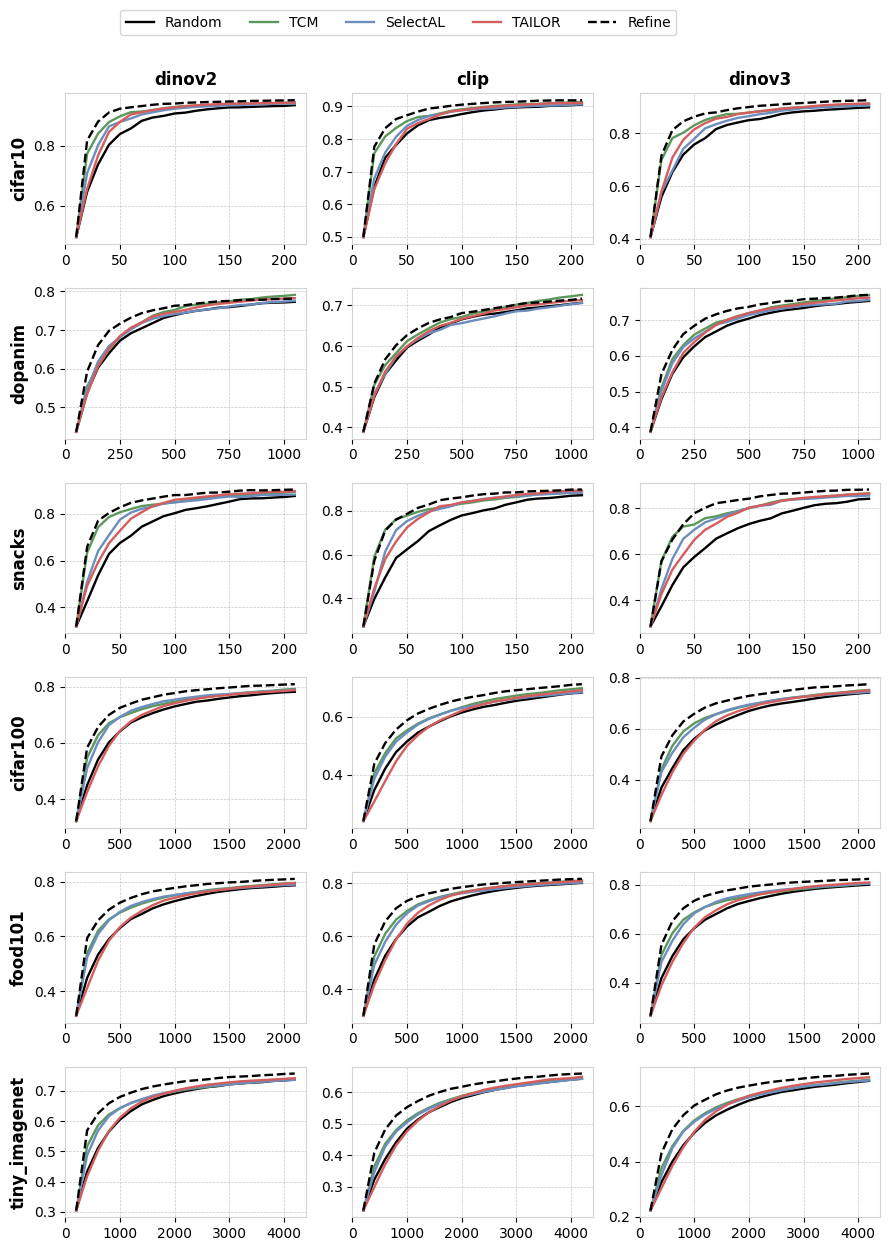

In [198]:
plot_kwargs = {
    'refine':             dict(lw=1.7, ls='--', color='black', label='Refine'),
    'random':             dict(lw=1.7, ls='-', color='black', label='Random'),
    'select_al':          dict(lw=1.7, ls='-', color='C0', label='SelectAL'),
    'tailor2':            dict(lw=1.7, ls='-', color='C1', label='TAILOR'),
    'tcm':                dict(lw=1.7, ls='-', color='C2', label='TCM'),
    'autoal3':            dict(lw=1.7, ls='-', color='C3', label='AutoAL'),
}

strats = ['random', 'tcm', 'select_al', 'tailor2', 'refine']
all_datasets = ['cifar10', 'dopanim', 'snacks', 'cifar100', 'food101', 'tiny_imagenet']
all_models = ['dinov2', 'clip', 'dinov3']
nrows = len(all_datasets)
ncols = len(all_models)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols,2*nrows))

absolute = True
for i, ds in enumerate(all_datasets):
    for j, m in enumerate(all_models):
        plt.sca(axes[i, j])
        avg_lc_random = np.mean(all_lcs[m][ds]['random'], 0)
        axis = axis_ds[ds]

        for strat in strats:
            avg_lc = np.mean(all_lcs[m][ds][strat], 0)
            target = avg_lc 
            target -= 0 if absolute else avg_lc_random 
            plt.plot(axis, target, **plot_kwargs[strat])
        if i == 0:
            axes[i, j].set_title(m, fontsize=12, fontweight='bold')
        if j == 0:
            axes[i, j].set_ylabel(ds, fontsize=12, fontweight='bold')

    
    # text_y_pos = 0.15 if absolute else 0.95
    # ax[i_ds].text(0.95, text_y_pos, s, 
    #               transform=ax[i_ds].transAxes,
    #               fontsize=11, fontweight='bold',
    #               verticalalignment='top',
    #               horizontalalignment='right')
    # plt.ylim(bottom=-0.01)

plt.tight_layout()
axes[0, 0].legend(bbox_to_anchor=(.2, 1.6), loc='upper left', ncol=5)
# for a in ax[-4:]:
#     a.set_xlabel('Number of Labels')
# ax[0].set_ylabel('Accuracy Improvement')
# ax[4].set_ylabel('Accuracy Improvement')
lc_type = {True: 'absolute', False: 'relative'}
plt.savefig(plot_dir / f'main_results_ensemble_complete_{lc_type[absolute]}.pdf', bbox_inches='tight')

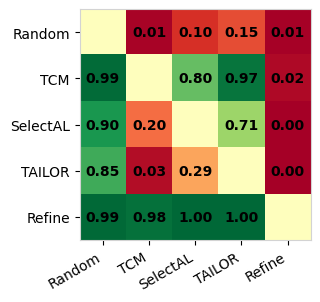

In [199]:
all_mats = []
for model in all_models:
    for dataset in all_datasets:
        mat, names = create_pairwise_comparison_matrix(all_lcs[model][dataset])
        all_mats.append(mat)
avg_mat = np.mean(all_mats, axis=0)

strat_order = ['random', 'tcm', 'select_al', 'tailor2', 'refine']
indices_order = [names.index(s) for s in strat_order]

avg_mat = avg_mat[np.ix_(indices_order, indices_order)]
np.fill_diagonal(avg_mat, 0.5)
names = [names[i] for i in indices_order]

plt.figure(figsize=(4, 3))
plt.grid()
plt.imshow(avg_mat, cmap='RdYlGn')
for i in range(len(names)):
    for j in range(len(names)):
        if i == j:continue
        text = plt.text(j, i, f'{avg_mat[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')
        # text.set_path_effects([patheffects.Stroke(linewidth=1.2, foreground='white'), patheffects.Normal()])

names = ['Random', 'TCM', 'SelectAL', 'TAILOR', 'Refine']
plt.xticks(range(len(mat)), names, rotation=30, ha='right')
plt.yticks(range(len(mat)), names)
plt.savefig(plot_dir / f'avg_pairwise_comparison_matrix_ensembles.pdf', bbox_inches='tight')
plt.show()

## Ablations

In [4]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/refine.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

[('main_results_v1', '23-10-25'), ('Default', '23-10-25')]

### How does filtering depth influence candidate pool quality?

We investigate how the number of filtering rounds $R$ affects the quality of the candidate pool $\mathcal{C}_R$. For each $R \in \{1, 2, 3, 4, 5\}$, we apply progressive filtering and then perform **random sampling** from the resulting $\mathcal{C}_R$. This isolates the effect of filtering depth from any particular selection strategy.

**Hypothesis:** Increasing $R$ should improve pool quality by more effectively filtering noise (as formalized in Theorem 2), leading to better performance even with random selection. However, we also expect diminishing returns or potential degradation if $R$ becomes too large, as the pool may shrink excessively (losing valuable instances) or converge to a limited subset that lacks diversity.

In [5]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/ablations.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

[('ablation_batches', '25-10-25'),
 ('ablation_depth', '25-10-25'),
 ('ablation_alpha', '24-10-25'),
 ('Default', '24-10-25')]

In [6]:
dataset= 'snacks'
backbone= 'dinov2'
num_batches = 50
init_query_list = [f"parameter.dataset.name = '{dataset}'", f"parameter.model.backbone = '{backbone}'"]
init_query_list_refine = init_query_list + ["parameter.al.refine.select_strategy = 'random'", f"parameter.al.refine.num_batches = '{num_batches}'"]
exp_name = 'ablation_depth'
refine_runs = {
    # 'R=0': get_runs(baselines_uri, 'baselines', init_query_list + ["parameter.al.strategy = 'random'"]),
    'R=1': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '1'"]),
    'R=2': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '2'"]),
    'R=3': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '3'"]),
    'R=4': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '4'"]),
    'R=5': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '5'"]),
    'R=6': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '6'"]),
    'R=7': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '7'"]),
    'R=8': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '8'"]),
    'R=9': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '9'"]),
    'R=10': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.progressive_depth = '10'"]),
}
baseline_runs = {'random': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])}

Got 10 runs for experiments ablation_depth with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'", "parameter.al.refine.progressive_depth = '1'"].
Got 10 runs for experiments ablation_depth with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'", "parameter.al.refine.progressive_depth = '2'"].
Got 10 runs for experiments ablation_depth with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'", "parameter.al.refine.progressive_depth = '3'"].
Got 10 runs for experiments ablation_depth with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "param

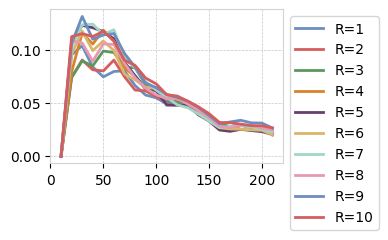

In [9]:
avg_lc_random = get_avg_lc(baseline_runs['random'], uri=baselines_uri)
axis = get_axis_from_run(refine_runs['R=1'][0])
for name in refine_runs:
    runs = refine_runs[name]
    avg_lc = get_avg_lc(runs, uri)
    plt.plot(axis, avg_lc - avg_lc_random, label=name, lw=2)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [ ]:
num_batches = 50
all_runs = get_runs(uri, 'ablation_depth', [f"parameter.al.refine.num_batches = '{num_batches}'"])

all_R = np.unique([eval(run.data.params['al.refine.progressive_depth']) for run in all_runs])
# all_R = all_R[all_R != 0]
all_backbones = np.unique([run.data.params['dataset.name'] for run in all_runs]).tolist()
# all_datasets.remove('cifar10')

axis_ds = {}
results_lcs = defaultdict(dict)
results_impr = defaultdict(dict)
for backbone in all_backbones:
    runs_backbone = [run for run in all_runs if run.data.params['dataset.name'] == backbone]
    axis_ds[backbone] = get_axis_from_run(runs_backbone[0])

    init_query_list = [f"parameter.dataset.name = '{backbone}'", f"parameter.model.backbone = '{backbone}'"]
    random_runs = get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])
    auc_random = np.mean(get_avg_lc(random_runs, baselines_uri))

    for val in all_R:
        runs_r = [run for run in runs_backbone if eval(run.data.params['al.refine.progressive_depth']) == val]
        # print(ds, val, len(runs_r))

        avg_lc = get_avg_lc(runs_r, uri)

        auc = np.mean(avg_lc, axis=0)
        # auc_stderr = np.std(avg_lc, axis=0) / np.sqrt(len(runs_r))
        auc_impr = ((auc - auc_random) / auc_random) * 100

        results_lcs[backbone][val] = avg_lc
        results_impr[backbone][val] = auc_impr

df = pd.DataFrame(results_impr)
df = df.rename(
    index={i: f"$R = {i}$" for i in df.index},
    columns={'cifar100': 'CIFAR-100', 'tiny_imagenet': 'Tiny ImageNet'}
)
df = df.applymap(lambda x: f"+\,{x:.2f}\\,\\%")
print(df.to_latex(column_format='l' + 'r' * len(df.columns)))

Got 200 runs for experiments ablation_depth with query ["parameter.al.refine.num_batches = '50'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].
\begin{tabular}{lrr}
\toprule
 & cifar10 & snacks \\
\midrule
$R = 1$ & +\,3.02\,\% & +\,6.91\,\% \\
$R = 2$ & +\,3.31\,\% & +\,6.75\,\% \\
$R = 3$ & +\,3.72\,\% & +\,7.22\,\% \\
$R = 4$ & +\,3.64\,\% & +\,7.68\,\% \\
$R = 5$ & +\,3.71\,\% & +\,7.79\,\% \\
$R = 6$ & +\,3.62\,\% & +\,7.53\,\% \\
$R = 7$ & +\,3.81\,\% & +\,8.10\,\% \\
$R = 8$ & +\,3.85\,\% & +\,7.64\,\% \\
$R = 9$ & +\,3.78\,\% & +\,8.43\,\% \\
$R = 10$ & +\,3.78\,\% & +\,8.35\,\% \\
\bottomrule
\end{tabular}



/tmp/ipykernel_3279752/1241642104.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: f"+\,{x:.2f}\\,\\%")


Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].


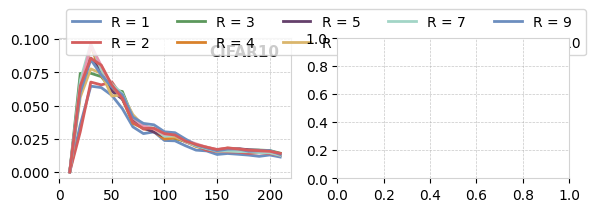

In [ ]:
absolute = False
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))
for i_ds, backbone in enumerate(['cifar10']):
    init_query_list = [f"parameter.dataset.name = '{backbone}'", f"parameter.model.backbone = '{backbone}'"]
    random_runs = get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])
    lc_random = get_avg_lc(random_runs, baselines_uri)

    plt.sca(ax[i_ds])

    lcs = results_lcs[backbone]
    axis = axis_ds[backbone]
    for val in lcs:
        lc = lcs[val]
        target = lc if absolute else lc - lc_random
        plt.plot(axis, target, label=f'R = {val}', lw=2)

    text_y_pos = 0.15 if absolute else 0.95
    ax[i_ds].text(0.95, text_y_pos, backbone.upper(), 
                  transform=ax[i_ds].transAxes,
                  fontsize=11, fontweight='bold',
                  verticalalignment='top',
                  horizontalalignment='right')

plt.tight_layout()
ax[0].legend(loc='upper left', ncol=5, bbox_to_anchor=(0, 1.25))
plt.savefig(plot_dir / f'lc_relacc_depth.pdf', bbox_inches='tight')

### How does the number of batches per strategies effect the performance?

In [4]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/ablations.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

[('ablation_strats', '26-10-25'),
 ('ablation_batches', '25-10-25'),
 ('ablation_depth', '25-10-25'),
 ('ablation_alpha', '24-10-25'),
 ('Default', '24-10-25')]

In [5]:
dataset= 'snacks'
backbone= 'dinov2'
init_query_list = [f"parameter.dataset.name = '{dataset}'", f"parameter.model.backbone = '{backbone}'"]
init_query_list_refine = init_query_list + ["parameter.al.refine.select_strategy = 'random'"]
init_query_list_refine += ["parameter.al.refine.alpha = '0.4'"]

exp_name = 'ablation_batches'
refine_runs = {
    'm=1': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '10'"]),
    'm=3': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '30'"]),
    'm=5': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '50'"]),
    'm=7': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '70'"]),
    'm=10': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '100'"]),
    'm=11': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '110'"]),
    'm=13': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '130'"]),
    'm=15': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '150'"]),
    'm=17': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '170'"]),
    'm=20': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.num_batches = '170'"]),
}
baseline_runs = {'random': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])}

Got 10 runs for experiments ablation_batches with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.alpha = '0.4'", "parameter.al.refine.num_batches = '10'"].
Got 10 runs for experiments ablation_batches with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.alpha = '0.4'", "parameter.al.refine.num_batches = '30'"].
Got 10 runs for experiments ablation_batches with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.alpha = '0.4'", "parameter.al.refine.num_batches = '50'"].
Got 10 runs for experiments ablation_batches with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.alpha =

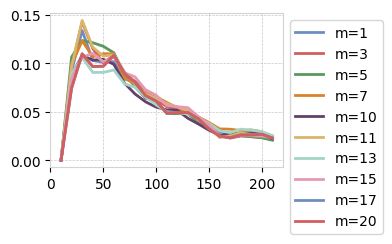

In [9]:
avg_lc_random = get_avg_lc(baseline_runs['random'], uri=baselines_uri)
axis = get_axis_from_run(refine_runs['m=1'][0])
for name in refine_runs:
    runs = refine_runs[name]
    avg_lc = get_avg_lc(runs, uri)
    plt.plot(axis, avg_lc - avg_lc_random, label=name, lw=2)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [ ]:
all_runs = get_runs(uri, 'ablation_batches', ["parameter.al.refine.alpha = '0.4'"])

all_backbones = np.unique([run.data.params['dataset.name'] for run in all_runs]).tolist()
# all_datasets.remove('cifar10')
all_num_batches = np.unique([eval(run.data.params['al.refine.num_batches']) for run in all_runs]).tolist()
# all_num_batches = [i*9 for i in [1, 2, 3, 5, 10]]
all_num_batches = [10, 30, 50, 70, 100, 110, 130, 150, 170, 200]


axis_ds = {}
results_lcs = defaultdict(dict)
results_impr = defaultdict(dict)
for backbone in all_backbones:
    runs_backbone = [run for run in all_runs if run.data.params['dataset.name'] == backbone]
    axis_ds[backbone] = get_axis_from_run(runs_backbone[0])

    init_query_list = [f"parameter.dataset.name = '{backbone}'", f"parameter.model.backbone = '{backbone}'"]
    random_runs = get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])
    auc_random = np.mean(get_avg_lc(random_runs, baselines_uri))

    for num_batches in all_num_batches:
        runs_num_batches = [run for run in runs_backbone if eval(run.data.params['al.refine.num_batches']) == num_batches]
        # print(ds, num_batches, len(runs_num_batches))
        avg_lc = get_avg_lc(runs_num_batches, uri)
        auc = np.mean(avg_lc, axis=0)

        auc_impr = ((auc - auc_random) / auc_random) * 100

        results_lcs[backbone][num_batches] = avg_lc
        results_impr[backbone][num_batches] = auc_impr

df = pd.DataFrame(results_impr)
df = df.rename(
    index={i: f"$m = {i // 9}$" for i in df.index},
    columns={'cifar100': 'CIFAR-100', 'tiny_imagenet': 'Tiny ImageNet'}
)
df = df.applymap(lambda x: f"+\\,{x:.2f}\\,\\%")
print(df.to_latex(column_format='l' + 'r' * len(df.columns)))

Got 200 runs for experiments ablation_batches with query ["parameter.al.refine.alpha = '0.4'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].
\begin{tabular}{lrr}
\toprule
 & cifar10 & snacks \\
\midrule
$m = 1$ & +\,3.57\,\% & +\,7.88\,\% \\
$m = 3$ & +\,3.77\,\% & +\,7.88\,\% \\
$m = 5$ & +\,3.71\,\% & +\,7.79\,\% \\
$m = 7$ & +\,3.85\,\% & +\,8.08\,\% \\
$m = 11$ & +\,3.79\,\% & +\,7.22\,\% \\
$m = 12$ & +\,3.89\,\% & +\,8.05\,\% \\
$m = 14$ & +\,3.85\,\% & +\,7.30\,\% \\
$m = 16$ & +\,4.08\,\% & +\,7.74\,\% \\
$m = 18$ & +\,3.75\,\% & +\,7.33\,\% \\
$m = 22$ & +\,3.93\,\% & +\,7.69\,\% \\
\bottomrule
\end{tabular}



/tmp/ipykernel_3281121/392749400.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: f"+\\,{x:.2f}\\,\\%")


### How does the subsample factor influence the selection?

In [12]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/ablations.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

[('ablation_batches', '25-10-25'),
 ('ablation_depth', '25-10-25'),
 ('ablation_alpha', '24-10-25'),
 ('Default', '24-10-25')]

In [16]:
dataset= 'snacks'
backbone= 'dinov2'
init_query_list = [f"parameter.dataset.name = '{dataset}'", f"parameter.model.backbone = '{backbone}'"]
init_query_list_refine = init_query_list + ["parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'"]
exp_name = 'ablation_alpha'
refine_runs = {
    'alpha=0.1': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.1'"]),
    'alpha=0.2': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.2'"]),
    'alpha=0.3': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.3'"]),
    'alpha=0.4': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.4'"]),
    'alpha=0.5': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.5'"]),
    'alpha=0.6': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.6'"]),
    'alpha=0.7': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.7'"]),
    'alpha=0.8': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.8'"]),
    'alpha=0.9': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '0.9'"]),
    'alpha=1.0': get_runs(uri, exp_name, init_query_list_refine + ["parameter.al.refine.alpha = '1.0'"]),
}
baseline_runs = {'random': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])}

Got 10 runs for experiments ablation_alpha with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'", "parameter.al.refine.alpha = '0.1'"].
Got 10 runs for experiments ablation_alpha with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'", "parameter.al.refine.alpha = '0.2'"].
Got 10 runs for experiments ablation_alpha with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'", "parameter.al.refine.alpha = '0.3'"].
Got 10 runs for experiments ablation_alpha with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '

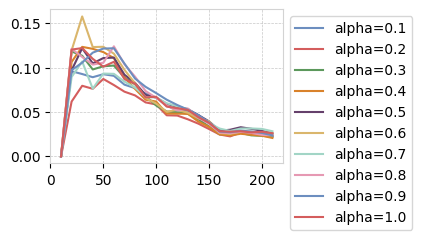

In [18]:
avg_lc_reference = get_avg_lc(baseline_runs['random'], uri=baselines_uri)
# avg_lc_reference = get_avg_lc(refine_runs['alpha=0.1'], uri=uri)
axis = get_axis_from_run(refine_runs['alpha=0.1'][0])
for name in refine_runs:
    runs = refine_runs[name]
    avg_lc = get_avg_lc(runs, uri)
    plt.plot(axis, avg_lc - avg_lc_reference, label=name)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [ ]:
num_batches = 45
query = ["parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'"]
all_runs = get_runs(uri, 'ablation_alpha', query_list=query)

all_alphas = np.unique([eval(run.data.params['al.refine.alpha']) for run in all_runs])
# all_alphas = [0.1, 0.3, 0.5]
all_datasets = np.unique([run.data.params['dataset.name'] for run in all_runs]).tolist()
# all_datasets.remove('cifar10')


results_lcs = defaultdict(dict)
results_impr = defaultdict(dict)
for backbone in all_datasets:
    runs_backbone = [run for run in all_runs if run.data.params['dataset.name'] == backbone]

    init_query_list = [f"parameter.dataset.name = '{backbone}'", f"parameter.model.backbone = '{backbone}'",]
    random_runs = get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])
    auc_random = np.mean(get_avg_lc(random_runs, baselines_uri))

    for alpha in all_alphas:
        runs_alpha = [run for run in runs_backbone if eval(run.data.params['al.refine.alpha']) == alpha]
#         print(ds, alpha, len(runs_alpha))
        avg_lc = get_avg_lc(runs_alpha, uri)
        auc = np.mean(avg_lc, axis=0)

        auc_impr = ((auc - auc_random) / auc_random) * 100

        results_lcs[backbone][alpha] = avg_lc
        results_impr[backbone][alpha] = auc_impr

df = pd.DataFrame(results_impr)
df = df.rename(
    index={i: f"$\\alpha = {i}$" for i in df.index},
    columns={'cifar100': 'CIFAR-100', 'tiny_imagenet': 'Tiny ImageNet'}
)
df = df.applymap(lambda x: f"+\\,{x:.2f}\\,\\%")
print(df.to_latex(column_format='l' + 'r' * len(df.columns)))

Got 200 runs for experiments ablation_alpha with query ["parameter.al.refine.select_strategy = 'random'", "parameter.al.refine.num_batches = '50'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].
\begin{tabular}{lrr}
\toprule
 & cifar10 & snacks \\
\midrule
$\alpha = 0.1$ & +\,3.11\,\% & +\,7.37\,\% \\
$\alpha = 0.2$ & +\,3.33\,\% & +\,6.32\,\% \\
$\alpha = 0.3$ & +\,3.89\,\% & +\,7.60\,\% \\
$\alpha = 0.4$ & +\,3.71\,\% & +\,7.79\,\% \\
$\alpha = 0.5$ & +\,3.62\,\% & +\,8.16\,\% \\
$\alpha = 0.6$ & +\,3.47\,\% & +\,8.49\,\% \\
$\alpha = 0.7$ & +\,3.97\,\% & +\,7.53\,\% \\
$\alpha = 0.8$ & +\,3.53\,\% & +\,8.22\,\% \\
$\alpha = 0.9$ & +\,3.70\,\% & +\,8.40\,\% \\
$\alpha = 1.0$ & +\,3.85\,\% & +\,8.06\,\%

/tmp/ipykernel_3279752/3760619786.py:36: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: f"+\\,{x:.2f}\\,\\%")


Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'snacks'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].


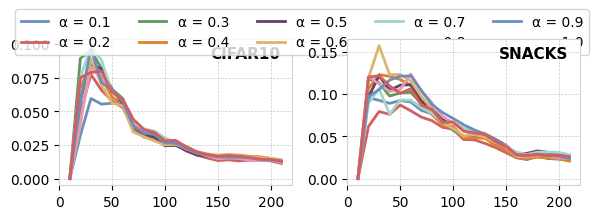

In [ ]:
absolute = False
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))
for i_ds, backbone in enumerate(['cifar10', 'snacks']):
    init_query_list = [f"parameter.dataset.name = '{backbone}'", f"parameter.model.backbone = '{backbone}'"]
    random_runs = get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"])
    lc_random = get_avg_lc(random_runs, baselines_uri)

    plt.sca(ax[i_ds])

    lcs = results_lcs[backbone]
    axis = axis_ds[backbone]
    for val in lcs:
        lc = lcs[val]
        target = lc if absolute else lc - lc_random
        plt.plot(axis, target, label=f'α = {val}', lw=2)

    text_y_pos = 0.15 if absolute else 0.95
    ax[i_ds].text(0.95, text_y_pos, backbone.upper(), 
                  transform=ax[i_ds].transAxes,
                  fontsize=11, fontweight='bold',
                  verticalalignment='top',
                  horizontalalignment='right')

plt.tight_layout()
ax[0].legend(loc='upper left', ncol=5, bbox_to_anchor=(-.22, 1.25))
plt.savefig(plot_dir / f'lc_relacc_alpha.pdf', bbox_inches='tight')

### Does progressive filtering improve the selection of AL strategies?

In [7]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/ablations.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

2025/11/11 15:55:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/11 15:55:33 INFO mlflow.store.db.utils: Updating database tables
2025-11-11 15:55:33 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-11 15:55:33 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-11 15:55:33 INFO  [alembic.runtime.migration] Running upgrade 0584bdc529eb -> 400f98739977, add logged model tables
2025-11-11 15:55:33 INFO  [alembic.runtime.migration] Running upgrade 400f98739977 -> 6953534de441, add step to inputs table
2025-11-11 15:55:33 INFO  [alembic.runtime.migration] Running upgrade 6953534de441 -> bda7b8c39065, increase_model_version_tag_value_limit
2025-11-11 15:55:33 INFO  [alembic.runtime.migration] Running upgrade bda7b8c39065 -> cbc13b556ace, add V3 trace schema columns
2025-11-11 15:55:33 INFO  [alembic.runtime.migration] Running upgrade cbc13b556ace -> 770bee3ae1dd, add assessments table
2025-11-11 15:55:33 INFO  [ale

[('ablation_value', '28-10-25'),
 ('tmp', '28-10-25'),
 ('ablation_strats', '26-10-25'),
 ('ablation_batches', '25-10-25'),
 ('ablation_depth', '25-10-25'),
 ('ablation_alpha', '24-10-25'),
 ('Default', '24-10-25')]

In [8]:
baselines_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db'
exp_name = 'baselines_v1'
dataset = 'cifar100'
all_backbones = ['dinov2', 'dinov3']
init_query_list = [f"parameter.dataset.name = '{dataset}'"]
# init_query_list = [f"parameter.model.backbone = '{backbone}'"]

all_baseline_runs = []
all_baseline_runs.extend(get_runs(baselines_uri, exp_name, init_query_list + [f"parameter.model.backbone = '{all_backbones[0]}'"]))
all_baseline_runs.extend(get_runs(baselines_uri, exp_name, init_query_list + [f"parameter.model.backbone = '{all_backbones[1]}'"]))

# all_strats = ['unc_herding', 'dropquery']
all_strats = ['random', 'alfamix', 'dropquery', 'typiclust', 'bait', 'unc_herding']

results_auc = defaultdict(dict)
results_lc = defaultdict(dict)
for backbone in all_backbones:
    runs_backbone = [run for run in all_baseline_runs if run.data.params['model.backbone'] == backbone]
    for strat in all_strats:
        strat_ = 'uncertainty_herding' if strat == 'unc_herding' else strat
        runs_strat = [run for run in runs_backbone if run.data.params['al.strategy'] == strat_]

        print(backbone, strat, len(runs_strat))
        avg_lc = get_avg_lc(runs_strat, baselines_uri)
        auc = np.mean(avg_lc)
        results_lc[backbone][strat] = avg_lc
        results_auc[backbone][strat] = auc

all_runs = get_runs(uri, 'ablation_strats', init_query_list)
# all_strats = np.unique([run.data.params['al.refine.select_strategy'] for run in all_runs]).tolist()

for backbone in all_backbones:
    runs_backbone = [run for run in all_runs if run.data.params['model.backbone'] == backbone]
    for strat in all_strats:
        runs_strat = [run for run in runs_backbone if run.data.params['al.refine.select_strategy'] == strat]
        print(backbone, strat, len(runs_strat))

        avg_lc = get_avg_lc(runs_strat, uri)
        auc = np.mean(avg_lc)
        results_lc[backbone]['filter_'+strat] = avg_lc
        results_auc[backbone]['filter_'+strat] = auc

Got 90 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.model.backbone = 'dinov2'"].
Got 90 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.model.backbone = 'dinov3'"].
dinov2 random 10
dinov2 alfamix 10
dinov2 dropquery 10
dinov2 typiclust 10
dinov2 bait 10
dinov2 unc_herding 10
dinov3 random 10
dinov3 alfamix 10
dinov3 dropquery 10
dinov3 typiclust 10
dinov3 bait 10
dinov3 unc_herding 10
Got 120 runs for experiments ablation_strats with query ["parameter.dataset.name = 'cifar100'"].
dinov2 random 10
dinov2 alfamix 10
dinov2 dropquery 10
dinov2 typiclust 10
dinov2 bait 10
dinov2 unc_herding 10
dinov3 random 10
dinov3 alfamix 10
dinov3 dropquery 10
dinov3 typiclust 10
dinov3 bait 10
dinov3 unc_herding 10


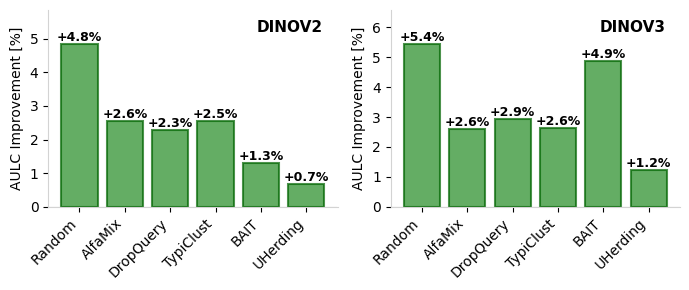

In [9]:
improvements = defaultdict(dict)
for backbone in all_backbones:
    for strat in all_strats:
        baseline = results_auc[backbone][strat]
        filtered = results_auc[backbone][f'filter_{strat}']
        improvement = ((filtered - baseline) / baseline) * 100
        improvements[backbone][strat] = improvement

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

labels = {
    'random': 'Random',
    'unc_herding': 'UHerding',
    'dropquery': 'DropQuery',
    'alfamix': 'AlfaMix',
    'typiclust': 'TypiClust',
    'bait': 'BAIT',
}

absolute = False
for i_ds, backbone  in enumerate(all_backbones):
    ax = axes[i_ds]
    plt.sca(ax)
    values = [improvements[backbone][s] for s in all_strats]
    
    x_pos = np.arange(len(all_strats))
    bars = plt.bar(x_pos, values, color='forestgreen', alpha=0.7, ec='darkgreen', lw=1.5)
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'+{val:.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel('AULC Improvement [%]')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([labels[strat] for strat in all_strats], rotation=45, ha='right')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.3)
    ax.grid()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    text_y_pos = 0.15 if absolute else 0.95
    ax.text(0.95, text_y_pos, backbone.upper(), 
                  transform=ax.transAxes, fontsize=11, fontweight='bold', va='top', ha='right')
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.15)  # Add 15% padding for labels

plt.tight_layout()
plt.savefig(plot_dir / f'aulc_improvments.pdf', bbox_inches='tight')


Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov2'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov3'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov2'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov3'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov2'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'din

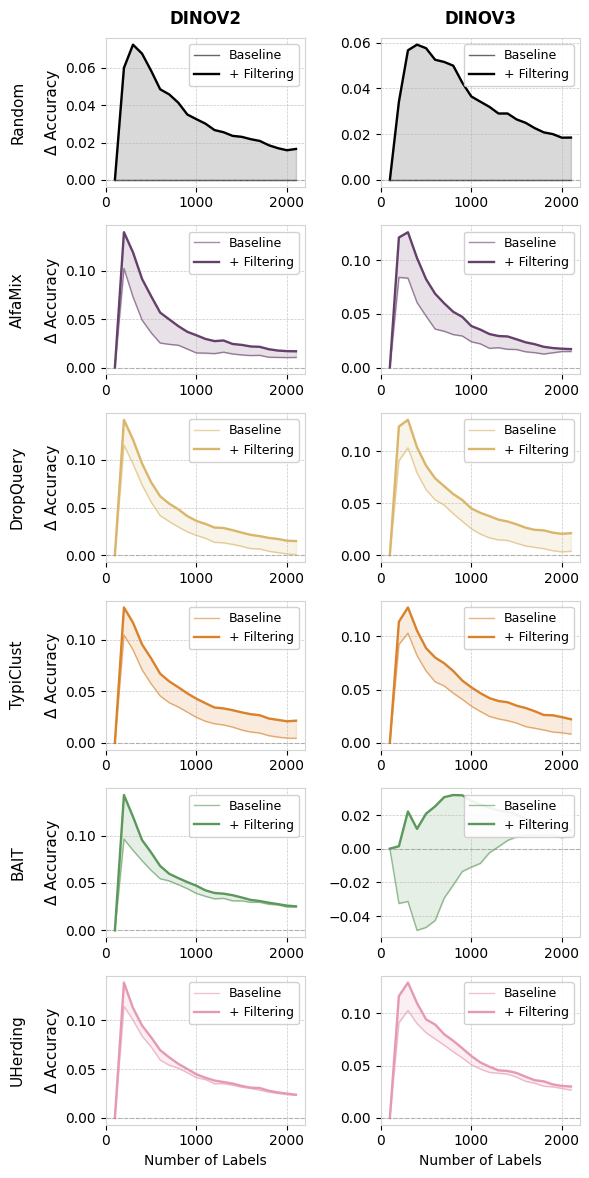

In [10]:
import matplotlib.pyplot as plt
import numpy as np

absolute = False
# Create larger figure for appendix - strategies as rows, datasets as columns
n_strats = len(all_strats)
n_backbones = len(all_backbones)

# fig, axes = plt.subplots(nrows=n_strats, ncols=n_backbones, figsize=(3 * n_backbones, 2 * n_strats),)
fig, axes = plt.subplots(nrows=n_strats, ncols=n_backbones, figsize=(3 * n_backbones, 2 * n_strats),)

# Ensure axes is 2D even with single row/column
if n_strats == 1:
    axes = axes.reshape(1, -1)
if n_backbones == 1:
    axes = axes.reshape(-1, 1)

# Plot styling
plot_kwargs_baseline = {
    'refine':               dict(lw=1, ls='--', color='black', label='Baseline', alpha=0.6),
    'random':               dict(lw=1, ls='-', color='black', label='Baseline', alpha=0.6),
    'margin':               dict(lw=1, ls='-', color='C0', label='Baseline', alpha=0.6),
    'badge':                dict(lw=1, ls='-', color='C1', label='Baseline', alpha=0.6),
    'bait':                 dict(lw=1, ls='-', color='C2', label='Baseline', alpha=0.6),
    'typiclust':            dict(lw=1, ls='-', color='C3', label='Baseline', alpha=0.6),
    'alfamix':              dict(lw=1, ls='-', color='C4', label='Baseline', alpha=0.6),
    'dropquery':            dict(lw=1, ls='-', color='C5', label='Baseline', alpha=0.6),
    'max_herding':          dict(lw=1, ls='-', color='C6', label='Baseline', alpha=0.6),
    'unc_herding':          dict(lw=1, ls='-', color='C7', label='Baseline', alpha=0.6),
}

plot_kwargs_filtered = {
    'refine':               dict(lw=1.7, ls='--', color='black', label='+ Filtering'),
    'random':               dict(lw=1.7, ls='-', color='black', label='+ Filtering'),
    'margin':               dict(lw=1.7, ls='-', color='C0', label='+ Filtering'),
    'badge':                dict(lw=1.7, ls='-', color='C1', label='+ Filtering'),
    'bait':                 dict(lw=1.7, ls='-', color='C2', label='+ Filtering'),
    'typiclust':            dict(lw=1.7, ls='-', color='C3', label='+ Filtering'),
    'alfamix':              dict(lw=1.7, ls='-', color='C4', label='+ Filtering'),
    'dropquery':            dict(lw=1.7, ls='-', color='C5', label='+ Filtering'),
    'max_herding':          dict(lw=1.7, ls='-', color='C6', label='+ Filtering'),
    'unc_herding':  dict(lw=1.7, ls='-', color='C7', label='+ Filtering'),
}

strategy_labels = {
    'random': 'Random',
    'unc_herding': 'UHerding',
    'dropquery': 'DropQuery',
    'alfamix': 'AlfaMix',
    'typiclust': 'TypiClust',
    'bait': 'BAIT',
}

# Plot each strategy-dataset combination
for i_strat, strat in enumerate(all_strats):
    for i_ds, backbone in enumerate(all_backbones):
        ax = axes[i_strat, i_ds]
        plt.sca(ax)
        
        # Get random baseline
        random_runs = get_runs(baselines_uri, 'baselines_v1', 
                              init_query_list + ["parameter.al.strategy = 'random'", 
                                                f"parameter.model.backbone = '{backbone}'"])
        lc_random = get_avg_lc(random_runs, baselines_uri)
        axis = get_axis_from_run(random_runs[0])
        
        results_lc_ds = results_lc[backbone]
        
        # Plot baseline strategy
        lc_baseline = results_lc_ds[strat]
        target_baseline = lc_baseline if absolute else lc_baseline - lc_random
        ax.plot(axis, target_baseline, **plot_kwargs_baseline[strat])
        
        # Plot filtered strategy
        lc_filtered = results_lc_ds[f'filter_{strat}']
        target_filtered = lc_filtered if absolute else lc_filtered - lc_random
        ax.plot(axis, target_filtered, **plot_kwargs_filtered[strat])
        
        # Shade improvement region
        if not absolute:
            ax.fill_between(axis, target_baseline, target_filtered, 
                           alpha=0.15, color=plot_kwargs_filtered[strat]['color'])
        
        if not absolute:
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        if i_strat == 0:
            ax.set_title(backbone.upper().replace('_', '-'), 
                        fontsize=12, fontweight='bold', pad=10)
        if i_ds == 0:
            ax.set_ylabel(strategy_labels[strat] + '\n\n' + ('Accuracy' if absolute else 'Δ Accuracy'), fontsize=11)

        ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
        
axes[-1, 0].set_xlabel('Number of Labels', fontsize=10)
axes[-1, -1].set_xlabel('Number of Labels', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(plot_dir / 'appendix_filtering_grid.pdf', bbox_inches='tight')
plt.show()

Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov2'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov3'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov2'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov3'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'dinov2'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar100'", "parameter.al.strategy = 'random'", "parameter.model.backbone = 'din

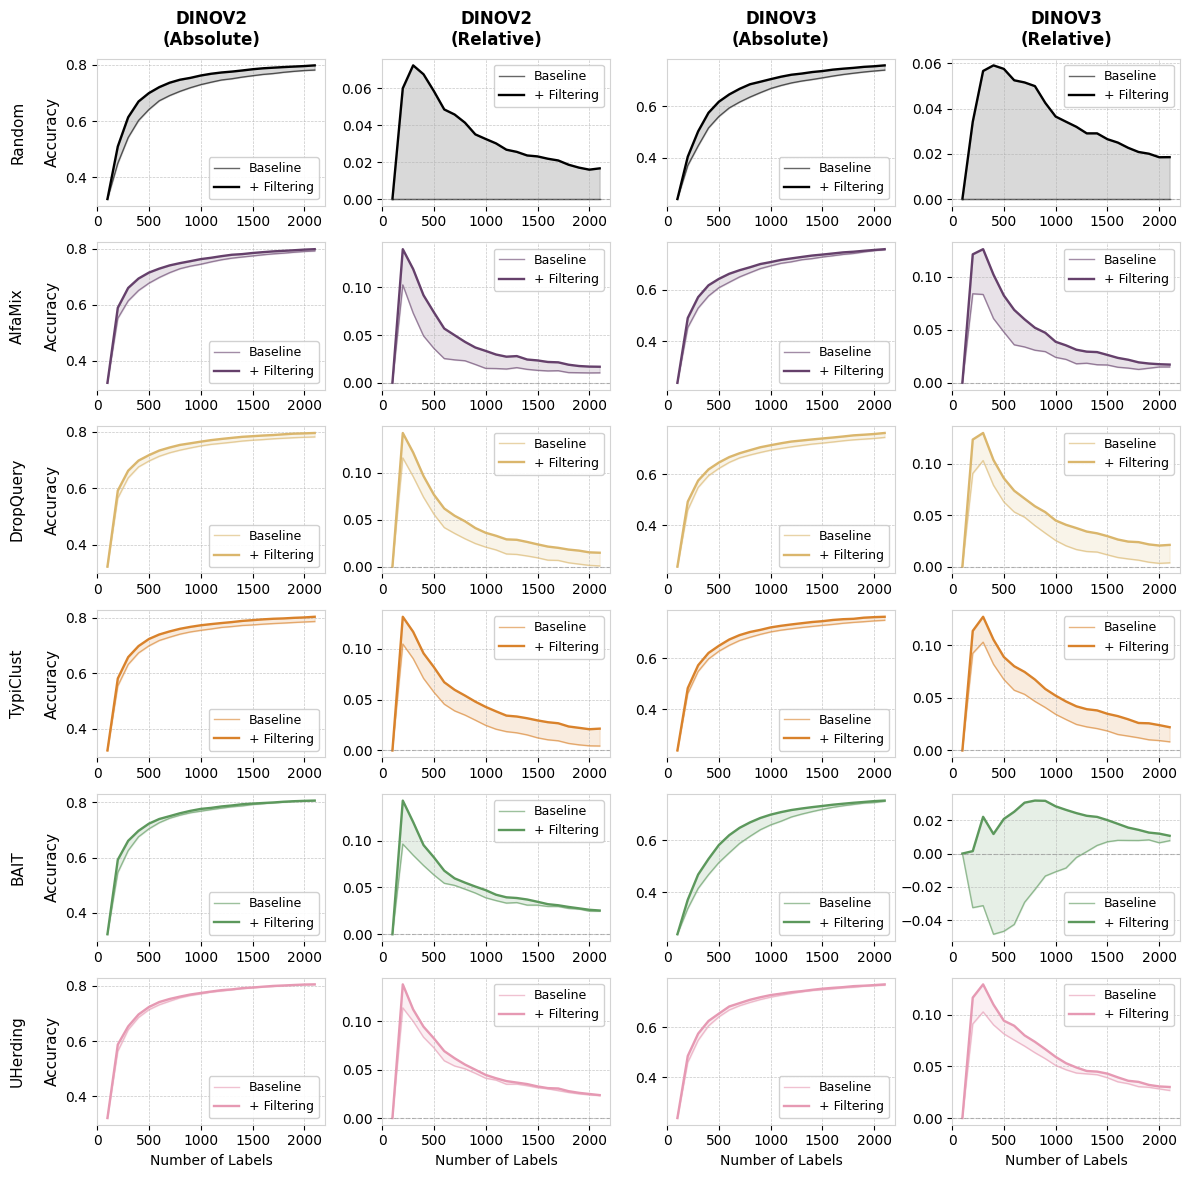

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create larger figure for appendix - strategies as rows, datasets*2 (absolute+relative) as columns
n_strats = len(all_strats)
n_backbones = len(all_backbones)

# Each backbone gets 2 columns: one for absolute, one for relative
fig, axes = plt.subplots(nrows=n_strats, ncols=2*n_backbones, 
                         figsize=(3 * 2 * n_backbones, 2 * n_strats))

# Ensure axes is 2D even with single row/column
if n_strats == 1:
    axes = axes.reshape(1, -1)
if 2*n_backbones == 1:
    axes = axes.reshape(-1, 1)

# Plot styling

strategy_labels = {
    'random': 'Random',
    'unc_herding': 'UHerding',
    'dropquery': 'DropQuery',
    'alfamix': 'AlfaMix',
    'typiclust': 'TypiClust',
    'bait': 'BAIT',
}

# Plot each strategy-dataset combination
for i_strat, strat in enumerate(all_strats):
    for i_ds, backbone in enumerate(all_backbones):
        # Get random baseline
        random_runs = get_runs(baselines_uri, 'baselines_v1', 
                              init_query_list + ["parameter.al.strategy = 'random'", 
                                                f"parameter.model.backbone = '{backbone}'"])
        lc_random = get_avg_lc(random_runs, baselines_uri)
        axis = get_axis_from_run(random_runs[0])
        
        results_lc_ds = results_lc[backbone]
        lc_baseline = results_lc_ds[strat]
        lc_filtered = results_lc_ds[f'filter_{strat}']
        
        # === ABSOLUTE PLOT (first column for this backbone) ===
        ax_abs = axes[i_strat, 2*i_ds]
        plt.sca(ax_abs)
        
        # Plot absolute learning curves
        ax_abs.plot(axis, lc_baseline, **plot_kwargs_baseline[strat])
        ax_abs.plot(axis, lc_filtered, **plot_kwargs_filtered[strat])
        
        # Shade improvement region for absolute
        ax_abs.fill_between(axis, lc_baseline, lc_filtered, 
                           alpha=0.15, color=plot_kwargs_filtered[strat]['color'])
        
        # Titles only on the first row
        if i_strat == 0:
            ax_abs.set_title(f'{backbone.upper().replace("_", "-")}\n(Absolute)', 
                            fontsize=12, fontweight='bold', pad=10)
        
        # Y-label for first column
        if i_ds == 0:
            ax_abs.set_ylabel(strategy_labels[strat] + '\n\nAccuracy', fontsize=11)
        
        ax_abs.legend(loc='lower right', fontsize=9, framealpha=0.9)
        
        # === RELATIVE PLOT (second column for this backbone) ===
        ax_rel = axes[i_strat, 2*i_ds + 1]
        plt.sca(ax_rel)
        
        # Plot relative learning curves
        target_baseline = lc_baseline - lc_random
        target_filtered = lc_filtered - lc_random
        
        ax_rel.plot(axis, target_baseline, **plot_kwargs_baseline[strat])
        ax_rel.plot(axis, target_filtered, **plot_kwargs_filtered[strat])
        
        # Shade improvement region for relative
        ax_rel.fill_between(axis, target_baseline, target_filtered, 
                           alpha=0.15, color=plot_kwargs_filtered[strat]['color'])
        
        # Zero line for relative plots
        ax_rel.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
        
        # Titles only on the first row
        if i_strat == 0:
            ax_rel.set_title(f'{backbone.upper().replace("_", "-")}\n(Relative)', 
                            fontsize=12, fontweight='bold', pad=10)
        
        ax_rel.legend( fontsize=9, framealpha=0.9)
        
        # X-labels on last row
        if i_strat == n_strats - 1:
            ax_abs.set_xlabel('Number of Labels', fontsize=10)
            ax_rel.set_xlabel('Number of Labels', fontsize=10)

# axes[4, 3].legend()
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.subplots_adjust(wspace=0.25, hspace=0.25)  # Adjust these values
plt.savefig(plot_dir / 'appendix_filtering_grid.pdf', bbox_inches='tight')
plt.show()

<Axes: >

### Does progressive filtering ...?

In [5]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/ablations.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

2025/11/12 09:40:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/12 09:40:03 INFO mlflow.store.db.utils: Updating database tables
2025-11-12 09:40:03 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-12 09:40:03 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-12 09:40:03 INFO  [alembic.runtime.migration] Running upgrade 0584bdc529eb -> 400f98739977, add logged model tables
2025-11-12 09:40:03 INFO  [alembic.runtime.migration] Running upgrade 400f98739977 -> 6953534de441, add step to inputs table
2025-11-12 09:40:03 INFO  [alembic.runtime.migration] Running upgrade 6953534de441 -> bda7b8c39065, increase_model_version_tag_value_limit
2025-11-12 09:40:03 INFO  [alembic.runtime.migration] Running upgrade bda7b8c39065 -> cbc13b556ace, add V3 trace schema columns
2025-11-12 09:40:03 INFO  [alembic.runtime.migration] Running upgrade cbc13b556ace -> 770bee3ae1dd, add assessments table
2025-11-12 09:40:03 INFO  [ale

[('ablation_value', '28-10-25'),
 ('tmp', '28-10-25'),
 ('ablation_strats', '26-10-25'),
 ('ablation_batches', '25-10-25'),
 ('ablation_depth', '25-10-25'),
 ('ablation_alpha', '24-10-25'),
 ('Default', '24-10-25')]

Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.strategy = 'random'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.strategy = 'typiclust'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.strategy = 'margin'"].
Got 10 runs for experiments ablation_value with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.refine.select_strategy = 'random'"].
Got 10 runs for experiments ablation_value with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "

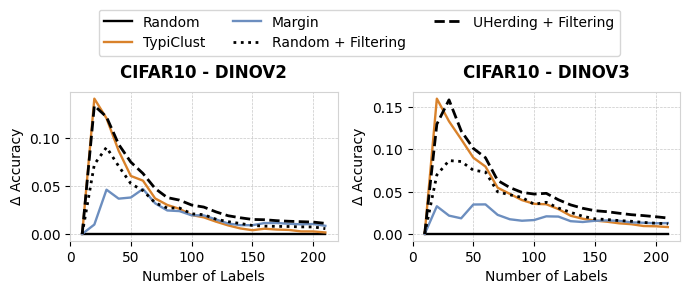

In [6]:
dataset = 'cifar10'
plot_kwargs = {
    'random':               dict(lw=1.7, ls='-', color='black', label='Random'),
    'margin':               dict(lw=1.7, ls='-', color='C0', label='Margin'),
    'badge':                dict(lw=1.7, ls='-', color='C1', label='BADGE'),
    'bait':                 dict(lw=1.7, ls='-', color='C2', label='BAIT'),
    'typiclust':            dict(lw=1.7, ls='-', color='C3', label='TypiClust'),
    'alfamix':              dict(lw=1.7, ls='-', color='C4', label='AlfaMix'),
    'dropquery':            dict(lw=1.7, ls='-', color='C5', label='DropQuery'),
    'max_herding':          dict(lw=1.7, ls='-', color='C6', label='MaxHerding'),
    'uncertainty_herding':  dict(lw=1.7, ls='-', color='C7', label='UHerding'),
    'typi+margin':          dict(lw=2, ls=':', color='black', label='Random + Filtering'),
    'refine':               dict(lw=2, ls='--', color='black', label='UHerding + Filtering'),
}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3.5*2, 2.5*1))

for i, backbone in enumerate(['dinov2', 'dinov3']):
    init_query_list = [f"parameter.dataset.name = '{dataset}'", f"parameter.model.backbone = '{backbone}'", "parameter.dataset.num_acq = '20'"]
    baseline_runs = {
        'random': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"]),
        'typiclust': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'typiclust'"]),
        'margin': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'margin'"]),
    }

    refine_runs = {
        'typi+margin': get_runs(uri, 'ablation_value', init_query_list + ["parameter.al.refine.select_strategy = 'random'"]),
        'refine': get_runs(uri, 'ablation_value', init_query_list + ["parameter.al.refine.select_strategy = 'unc_herding'"]),
    }

    avg_lc_reference = get_avg_lc(baseline_runs['random'], uri=baselines_uri)
    axis = get_axis_from_run(refine_runs['typi+margin'][0])
    ax = axes[i]
    plt.sca(ax)

    for name in ['random', 'typiclust', 'margin']:
        runs = baseline_runs[name]
        avg_lc = get_avg_lc(runs, baselines_uri)
        ax.plot(axis, avg_lc - avg_lc_reference, **plot_kwargs[name])

    for name in refine_runs:
        runs = refine_runs[name]
        avg_lc = get_avg_lc(runs, uri)
        ax.plot(axis, avg_lc - avg_lc_reference, **plot_kwargs[name])

    ax.set_xlabel('Number of Labels' )
    ax.set_ylabel('Δ Accuracy' )
    ax.set_title(f'{dataset.upper()} - {backbone.upper().replace("_", "-")}', fontweight='bold', pad=10)

plt.tight_layout()
plt.legend(loc='upper right', ncols=3, bbox_to_anchor=(.8, 1.6))
plt.savefig(plot_dir / f'ablation_value.pdf', bbox_inches='tight')
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1445099/3793194564.py:8: SyntaxWarning: invalid escape sequence '\m'
  'random':                dict(lw=1.7, ls='-', color='black', label='Random on $\mathcal{U}_t$'),
/tmp/ipykernel_1445099/3793194564.py:9: SyntaxWarning: invalid escape sequence '\m'
  'margin':                dict(lw=1.7, ls='-', color='C0', label='Margin on $\mathcal{U}_t$'),
/tmp/ipykernel_1445099/3793194564.py:12: SyntaxWarning: invalid escape sequence '\m'
  'typiclust':             dict(lw=1.7, ls='-'

Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.strategy = 'random'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.strategy = 'typiclust'"].
Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.strategy = 'margin'"].
Got 10 runs for experiments ablation_value with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "parameter.al.refine.select_strategy = 'random'"].
Got 10 runs for experiments ablation_value with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.dataset.num_acq = '20'", "

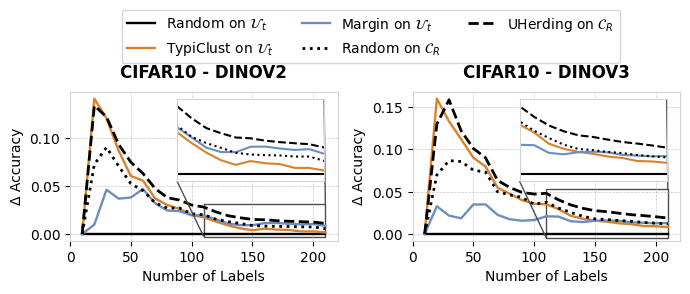

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset # --- NEW IMPORT ---

# --- Your original setup code ---
dataset = 'cifar10'
plot_kwargs = {
    'random':                dict(lw=1.7, ls='-', color='black', label='Random on $\mathcal{U}_t$'),
    'margin':                dict(lw=1.7, ls='-', color='C0', label='Margin on $\mathcal{U}_t$'),
    'badge':                 dict(lw=1.7, ls='-', color='C1', label='BADGE'),
    'bait':                  dict(lw=1.7, ls='-', color='C2', label='BAIT'),
    'typiclust':             dict(lw=1.7, ls='-', color='C3', label='TypiClust on $\mathcal{U}_t$'),
    'alfamix':               dict(lw=1.7, ls='-', color='C4', label='AlfaMix'),
    'dropquery':             dict(lw=1.7, ls='-', color='C5', label='DropQuery'),
    'max_herding':           dict(lw=1.7, ls='-', color='C6', label='MaxHerding'),
    'uncertainty_herding':   dict(lw=1.7, ls='-', color='C7', label='UHerding'),
    'typi+margin':           dict(lw=2, ls=':', color='black', label='Random on $\mathcal{C}_R$'),
    'refine':                dict(lw=2, ls='--', color='black', label='UHerding on $\mathcal{C}_R$'),
}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(3.5*2, 2.5*1))

for i, backbone in enumerate(['dinov2', 'dinov3']):
    init_query_list = [f"parameter.dataset.name = '{dataset}'", f"parameter.model.backbone = '{backbone}'", "parameter.dataset.num_acq = '20'"]
    baseline_runs = {
        'random': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'random'"]),
        'typiclust': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'typiclust'"]),
        'margin': get_runs(baselines_uri, 'baselines_v1', init_query_list + ["parameter.al.strategy = 'margin'"]),
    }

    refine_runs = {
        'typi+margin': get_runs(uri, 'ablation_value', init_query_list + ["parameter.al.refine.select_strategy = 'random'"]),
        'refine': get_runs(uri, 'ablation_value', init_query_list + ["parameter.al.refine.select_strategy = 'unc_herding'"]),
    }

    avg_lc_reference = get_avg_lc(baseline_runs['random'], uri=baselines_uri)
    axis = get_axis_from_run(refine_runs['typi+margin'][0])
    ax = axes[i]
    plt.sca(ax)

    # --- NEW: Store data for inset ---
    plotted_data = {}
    all_names = ['random', 'typiclust', 'margin'] + list(refine_runs.keys())
    # ---------------------------------

    for name in ['random', 'typiclust', 'margin']:
        runs = baseline_runs[name]
        avg_lc = get_avg_lc(runs, baselines_uri)
        y_data = avg_lc - avg_lc_reference # This is what we plot
        ax.plot(axis, y_data, **plot_kwargs[name])
        plotted_data[name] = y_data # --- NEW: Store it

    for name in refine_runs:
        runs = refine_runs[name]
        avg_lc = get_avg_lc(runs, uri)
        y_data = avg_lc - avg_lc_reference # This is what we plot
        ax.plot(axis, y_data, **plot_kwargs[name])
        plotted_data[name] = y_data # --- NEW: Store it

    # --- NEW: Create Inset ---
    
    zoom_start_index = int(len(axis) * 0.5) 
    x_min_zoom = axis[zoom_start_index]
    x_max_zoom = axis[-1]

    # 2. Find Y-limits for the zoomed region
    y_min_zoom = float('inf')
    y_max_zoom = float('-inf')
    for name in all_names:
        # Get the Y data corresponding to the zoomed X-axis
        y_data_zoomed_segment = plotted_data[name][zoom_start_index:]
        if len(y_data_zoomed_segment) > 0: # Ensure segment is not empty
            y_min_zoom = min(y_min_zoom, np.min(y_data_zoomed_segment))
            y_max_zoom = max(y_max_zoom, np.max(y_data_zoomed_segment))
    
    # Add 10% padding to Y-limits
    y_padding = (y_max_zoom - y_min_zoom) * 0.1
    y_min_zoom -= y_padding
    y_max_zoom += y_padding

    inset_position = [0.40, 0.4, 0.55, 0.55] 
    ax_inset = ax.inset_axes(inset_position)

    # 4. Re-plot all data on the inset
    for name in all_names:
        # We only need the kwargs, don't re-add labels to the legend
        inset_kwargs = plot_kwargs[name].copy()
        inset_kwargs['lw'] = 1.5
        inset_kwargs.pop('label', None) 
        ax_inset.plot(axis, plotted_data[name], **inset_kwargs)

    # 5. Set the limits for the zoom
    ax_inset.set_xlim(x_min_zoom, x_max_zoom)
    ax_inset.set_ylim(y_min_zoom, y_max_zoom)

    # 6. Tweak inset appearance
    ax_inset.set_xticks([]) # --- This disables x-ticks and labels
    ax_inset.set_yticks([]) # --- This disables y-ticks and labels
    ax_inset.grid(True, linestyle=':', alpha=0.7)

    # 7. Add indicator lines
    # loc1/loc2 are corners to connect (1=UR, 2=UL, 3=LL, 4=LR)
    mark_inset(ax, ax_inset, loc1=1, loc2=3, fc="none", ec="0.3")
    
    # --- End Inset ---

    ax.set_xlabel('Number of Labels' )
    ax.set_ylabel('Δ Accuracy' )
    ax.set_title(f'{dataset.upper()} - {backbone.upper().replace("_", "-")}', fontweight='bold', pad=10)

plt.tight_layout()
plt.legend(loc='upper right', ncols=3, bbox_to_anchor=(.8, 1.6))
plt.savefig(plot_dir / f'ablation_value.pdf', bbox_inches='tight')
plt.show()

## Grid Search

In [7]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/grid_search.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

[('grid_search_v1', '22-10-25'), ('Default', '22-10-25')]

In [8]:
backbone = 'dinov2'
dataset = 'cifar10'

query_list = [
    f"parameter.dataset.name = '{dataset}'",
    f"parameter.model.backbone = '{backbone}'",
]
all_runs = get_runs(uri, 'grid_search_v1', query_list=query_list)

Got 1214 runs for experiments grid_search_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'"].


In [9]:
all_alphas = np.unique([eval(run.data.params['al.refine.alpha']) for run in all_runs])
all_depths = np.unique([eval(run.data.params['al.refine.progressive_depth']) for run in all_runs])
all_batches = np.unique([eval(run.data.params['al.refine.num_batches']) for run in all_runs])
# all_batches = [50]
print(all_alphas, all_depths, all_batches)

[0.1 0.2 0.3 0.4 0.5] [1 2 3 4 5] [ 25  50  75 100 125]


In [ ]:
lcs_grid = {}
aucs_grid = np.zeros((len(all_alphas), len(all_depths), len(all_batches)))
for i_a, alpha in enumerate(all_alphas):
    for i_d, depth in enumerate(all_depths):
        for i_b, batch in enumerate(all_batches):
            runs_grid = [run for run in all_runs if eval(run.data.params['al.refine.alpha']) == alpha and 
                                                    eval(run.data.params['al.refine.progressive_depth']) == depth and
                                                    eval(run.data.params['al.refine.num_batches']) == batch ]
            print(alpha, depth, batch, len(runs_grid))
            avg_lc = get_avg_lc(runs_grid, uri)
            auc = np.mean(avg_lc) 
            if np.isnan(auc):
                auc = 0 
            lcs_grid[f'{alpha} - {depth} - {batch}'] = avg_lc
            aucs_grid[i_a, i_d, i_b] = auc
print(aucs_grid)

idx_best_alpha, idx_best_depth, idx_best_batch = np.unravel_index(np.argmax(aucs_grid), aucs_grid.shape)
print(f'Best Hyperparameters: α={all_alphas[idx_best_alpha]}, R={all_depths[idx_best_depth]}, m={all_batches[idx_best_batch]}')

0.1 1 25 10
0.1 1 50 10
0.1 1 75 10
0.1 1 100 10
0.1 1 125 10
0.1 2 25 10
0.1 2 50 10
0.1 2 75 10
0.1 2 100 10
0.1 2 125 10
0.1 3 25 10
0.1 3 50 10
0.1 3 75 10
0.1 3 100 10
0.1 3 125 10
0.1 4 25 10
0.1 4 50 10
0.1 4 75 10
0.1 4 100 10
0.1 4 125 10
0.1 5 25 10
0.1 5 50 10
0.1 5 75 10
0.1 5 100 10
0.1 5 125 10
0.2 1 25 10
0.2 1 50 10
0.2 1 75 10
0.2 1 100 10
0.2 1 125 10
0.2 2 25 10
0.2 2 50 10
0.2 2 75 10
0.2 2 100 10
0.2 2 125 10
0.2 3 25 10
0.2 3 50 10
0.2 3 75 10
0.2 3 100 10
0.2 3 125 10
0.2 4 25 10
0.2 4 50 10
0.2 4 75 10
0.2 4 100 10
0.2 4 125 10
0.2 5 25 10
0.2 5 50 10
0.2 5 75 10
0.2 5 100 10
0.2 5 125 10
0.3 1 25 10
0.3 1 50 10
0.3 1 75 10
0.3 1 100 10
0.3 1 125 10
0.3 2 25 10
0.3 2 50 10
0.3 2 75 10
0.3 2 100 10
0.3 2 125 3
0.3 3 25 10
0.3 3 50 10
0.3 3 75 10
0.3 3 100 10
0.3 3 125 4
0.3 4 25 9
0.3 4 50 10
0.3 4 75 10
0.3 4 100 9
0.3 4 125 10
0.3 5 25 10
0.3 5 50 10
0.3 5 75 10
0.3 5 100 6
0.3 5 125 10
0.4 1 25 10
0.4 1 50 0
0.4 1 75 10
0.4 1 100 10
0.4 1 125 10
0.4 2 25 10
0.

/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/dhuseljic/miniconda3/envs/dal-toolbox/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0.4 2 100 10
0.4 2 125 10
0.4 3 25 10
0.4 3 50 10
0.4 3 75 10
0.4 3 100 10
0.4 3 125 10
0.4 4 25 10
0.4 4 50 10
0.4 4 75 10
0.4 4 100 10
0.4 4 125 10
0.4 5 25 9
0.4 5 50 10
0.4 5 75 10
0.4 5 100 10
0.4 5 125 10
0.5 1 25 10
0.5 1 50 10
0.5 1 75 10
0.5 1 100 10
0.5 1 125 10
0.5 2 25 10
0.5 2 50 10
0.5 2 75 10
0.5 2 100 10
0.5 2 125 10
0.5 3 25 10
0.5 3 50 10
0.5 3 75 10
0.5 3 100 10
0.5 3 125 10
0.5 4 25 10
0.5 4 50 10
0.5 4 75 10
0.5 4 100 10
0.5 4 125 10
0.5 5 25 10
0.5 5 50 10
0.5 5 75 10
0.5 5 100 10
0.5 5 125 9
[[[0.9078019  0.91124333 0.91048905 0.91003857 0.90924714]
  [0.90728762 0.91017333 0.91040143 0.91108286 0.91001619]
  [0.90698857 0.90754714 0.91072667 0.91165238 0.91138619]
  [0.90557095 0.90846619 0.91099238 0.91175381 0.91064048]
  [0.90439714 0.90800381 0.91016571 0.90902143 0.9103219 ]]

 [[0.9078019  0.91124333 0.91048905 0.91003857 0.90924714]
  [0.90796619 0.90867619 0.91094905 0.90957566 0.9112    ]
  [0.9069     0.91079762 0.9102219  0.90894238 0.90995524]
  [0.9

Got 10 runs for experiments baselines_v1 with query ["parameter.dataset.name = 'cifar10'", "parameter.model.backbone = 'dinov2'", "parameter.al.strategy = 'random'"].


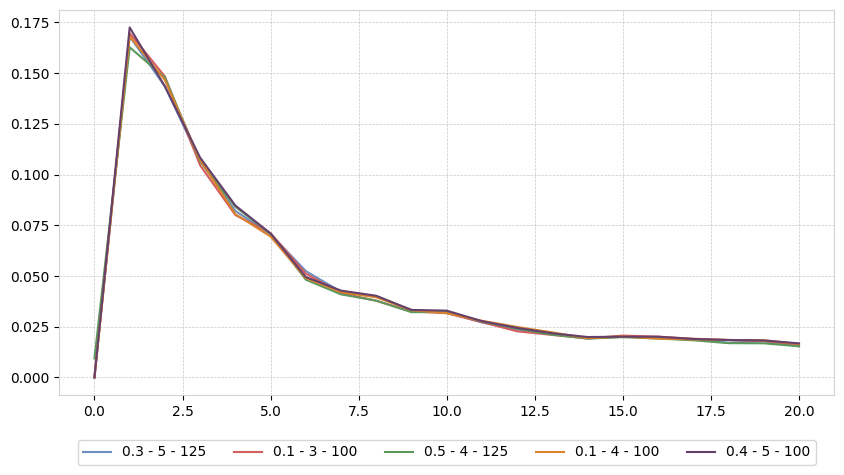

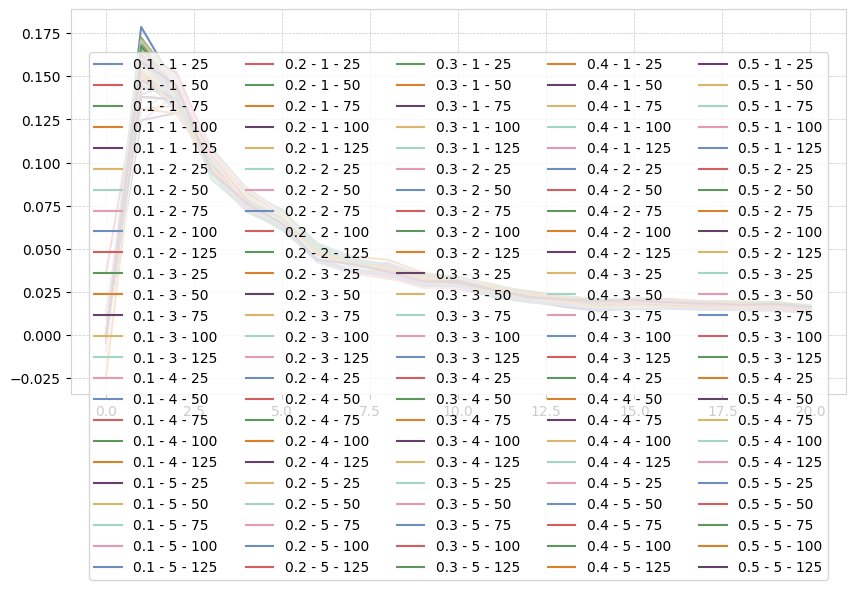

In [39]:
k = 5
flat_indices = topk_indices = np.unravel_index(np.argsort(aucs_grid.flatten())[-k:]
, aucs_grid.shape)
topk_indices = np.array(topk_indices).T

qlist = [f"parameter.dataset.name = '{dataset}'", f"parameter.model.backbone = '{backbone}'", "parameter.al.strategy = 'random'"]
runs_random = get_runs(baselines_uri, exp_name, qlist)

axis = get_axis_from_run(runs_random[0])
lc_random = get_avg_lc(runs_random, baselines_uri)

plt.figure(figsize=(10, 5))
for indices in topk_indices:
    key = f"{all_alphas[indices[0]]} - {all_depths[indices[1]]} - {all_batches[indices[2]]}"
    plt.plot(lcs_grid[key] - lc_random, label=key)
plt.legend(loc='lower center', ncols=5, bbox_to_anchor=(.5, -0.2))

plt.figure(figsize=(10, 5))
for key in lcs_grid:
    #key = f"{all_alphas[indices[0]]} - {all_depths[indices[1]]} - {all_batches[indices[2]]}"
    plt.plot(lcs_grid[key] - lc_random, label=key)
plt.legend(loc='lower center', ncols=5, bbox_to_anchor=(.5, -0.5))

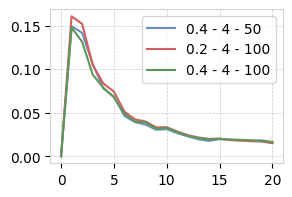

In [58]:
plt.plot(lcs_grid['0.4 - 4 - 50'] - lc_random, label='0.4 - 4 - 50')
plt.plot(lcs_grid['0.2 - 4 - 100'] - lc_random, label='0.2 - 4 - 100')
plt.plot(lcs_grid['0.4 - 4 - 100'] - lc_random, label='0.4 - 4 - 100')
plt.legend()

## DELETE FAILED AND DUPLICATE RUNS FROM DB (CAREFUL)

In [72]:
# Deleting failed runs, careful here
# client = mlflow.tracking.MlflowClient(tracking_uri='sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db')
# experiment_id = client.get_experiment_by_name('baselines_v1').experiment_id
# runs = client.search_runs(experiment_ids=experiment_id, max_results=10000)
# failed_runs = [run for run in runs if len(run.data.params) == 0]
# failed_run_ids = [run.info.run_id for run in failed_runs]
# for run_id in failed_run_ids:
#     client.delete_run(run_id=run_id)

# Deleting duplicates
# baselines_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db'
# dataset = ['cifar10', 'dopanim', 'snacks', 'cifar100', 'food101', 'tiny_imagenet', 'imagenet'][0]
# backbone = ['dinov2', 'clip', 'dinov3'][1]
# exp_name = 'baselines_v1'
# query_list = [f"parameter.dataset.name = 'cifar10'", f"parameter.model.backbone = 'dinov3'"]
# query_list = query_list + ["parameter.al.strategy = 'random'"]
# runs = get_runs(baselines_uri, exp_name, query_list=query_list)

# remove_ids = []
# for seed in range(10):
#     runs_seed = [run for run in runs if eval(run.data.params['random_seed']) == seed]
#     if len(runs_seed) > 1:
#         print(seed, len(runs_seed))
#         remove_ids.append(runs_seed[-1].info.run_id)
# for run_id in remove_ids:
#     client.delete_run(run_id=run_id)

# Deleting run which failed during logging -.-
# client = mlflow.tracking.MlflowClient(tracking_uri='sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db')
# baselines_uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/baselines.db'
# exp_name = 'baselines_v1'
# query_list = [f"parameter.dataset.name = 'imagenet'", f"parameter.model.backbone = 'clip'"]
# query_list = query_list + ["parameter.al.strategy = 'bait'"]
# runs = get_runs(baselines_uri, exp_name, query_list=query_list)
# for run in runs:
#     if len(get_metric(run, baselines_uri, 'accuracy')) != 21:
#         print(run.info.run_id)
# client.delete_run(run_id='94c1b71898a84c6bb4933887fb685b98')

In [23]:
runs[1].info.run_id

'5a6cc49d6aa74705ac93728d4458ea73'

## Audio Spectograms

In [5]:
uri = 'sqlite:////home/dhuseljic/mlflow/adaptive_al/audio.db'

client = mlflow.tracking.MlflowClient(tracking_uri=uri)
[(exp.name, datetime.date.fromtimestamp(exp.last_update_time/1000).strftime("%d-%m-%y")) for exp in client.search_experiments()]

2025/11/11 16:55:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/11 16:55:49 INFO mlflow.store.db.utils: Updating database tables
2025-11-11 16:55:49 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-11 16:55:49 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-11 16:55:49 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-11 16:55:49 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


[('audio_results_v5', '11-11-25'),
 ('audio_results_v4', '11-11-25'),
 ('audio_results_v3', '10-11-25'),
 ('audio_results_v2', '10-11-25'),
 ('audio_results_v1', '10-11-25'),
 ('Default', '10-11-25')]

In [6]:
exp_name = 'audio_results_v3'
runs = {
    'random': get_runs(uri, exp_name, ["parameter.al.strategy = 'random'"]),
    'margin': get_runs(uri, exp_name, ["parameter.al.strategy = 'margin'"]),
    'badge': get_runs(uri, exp_name, ["parameter.al.strategy = 'badge'"]),
    'bait': get_runs(uri, exp_name, ["parameter.al.strategy = 'bait'"]),
    'typiclust': get_runs(uri, exp_name, ["parameter.al.strategy = 'typiclust'"]),
    'max_herding': get_runs(uri, exp_name, ["parameter.al.strategy = 'max_herding'"]),
    'unc_herding': get_runs(uri, exp_name, ["parameter.al.strategy = 'uncertainty_herding'"]),
    'alfamix': get_runs(uri, exp_name, ["parameter.al.strategy = 'alfamix'"]),
    'dropquery': get_runs(uri, exp_name, ["parameter.al.strategy = 'dropquery'"]),
    # 'select_al': get_runs(baselines_uri, exp_name, [f"parameter.dataset.name = '{dataset}'", "parameter.al.strategy = 'select_al'"]),
    # 'tcm': get_runs(baselines_uri, exp_name, [f"parameter.dataset.name = '{dataset}'", "parameter.al.strategy = 'tcm'"]),
    # 'refine': get_runs(uri, 'audio_results_v2', ["parameter.al.strategy = 'refine'"]),
    'refine': get_runs(uri, 'audio_results_v3', ["parameter.al.strategy = 'refine'", "parameter.al.refine.select_strategy = 'max_herding'"]),
}

Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'random'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'margin'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'badge'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'bait'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'typiclust'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'max_herding'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'uncertainty_herding'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'alfamix'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'dropquery'"].
Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'refine'", "parameter.al.refine.select_strategy = 

In [19]:
exp_name = 'audio_results_v5'
runs = {
    'random': get_runs(uri, 'audio_results_v3', ["parameter.al.strategy = 'random'"]),
    # 'typiclust': get_runs(uri, 'audio_results_v3', ["parameter.al.strategy = 'typiclust'"]),
    'coreset': get_runs(uri, 'audio_results_v5', ["parameter.al.strategy = 'coreset'"]),
    'coreset + filter': get_runs(uri, 'audio_results_v5', ["parameter.al.strategy = 'refine'", "parameter.al.refine.select_strategy = 'coreset'"]),
}

Got 10 runs for experiments audio_results_v3 with query ["parameter.al.strategy = 'random'"].
Got 10 runs for experiments audio_results_v5 with query ["parameter.al.strategy = 'coreset'"].
Got 10 runs for experiments audio_results_v5 with query ["parameter.al.strategy = 'refine'", "parameter.al.refine.select_strategy = 'coreset'"].


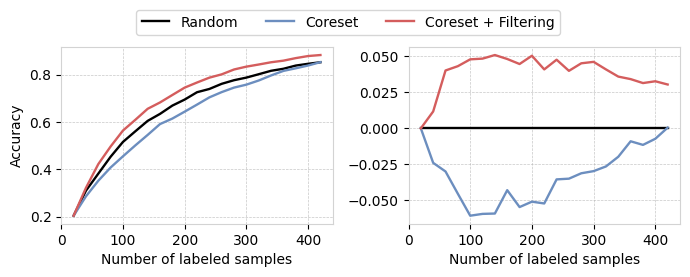

In [29]:
plot_kwargs = {
    'refine':               dict(lw=1.7, ls='--', color='black', label='Refine'),
    'random':               dict(lw=1.7, ls='-', color='black', label='Random'),
    'margin':               dict(lw=1.7, ls='-', color='C0', label='Margin'),
    'badge':                dict(lw=1.7, ls='-', color='C1', label='BADGE'),
    'bait':                 dict(lw=1.7, ls='-', color='C2', label='BAIT'),
    'typiclust':            dict(lw=1.7, ls='-', color='C3', label='TypiClust'),
    'alfamix':              dict(lw=1.7, ls='-', color='C4', label='AlfaMix'),
    'dropquery':            dict(lw=1.7, ls='-', color='C5', label='DropQuery'),
    'max_herding':          dict(lw=1.7, ls='-', color='C6', label='MaxHerding'),
    'unc_herding':          dict(lw=1.7, ls='-', color='C7', label='UHerding'),
    'coreset':              dict(lw=1.7, ls='-', color='C8', label='Coreset'),
    'coreset + filter':     dict(lw=1.7, ls='-', color='C9', label='Coreset + Filtering'),
}

axis = get_axis_from_run(runs['random'][0])
plt.figure(figsize=(3.5*2, 2.5))
ax = plt.subplot(121)
for key in runs:
    avg_lc = get_avg_lc(runs[key], uri)
    plt.plot(axis, avg_lc, **plot_kwargs[key])
# plt.plot(axis, avg_lc_old, '-o', label='old refine')
plt.xlabel('Number of labeled samples')
plt.ylabel('Accuracy')

plt.subplot(122)
for key in runs:
    avg_lc = get_avg_lc(runs[key], uri)
    avg_lc_random = get_avg_lc(runs['random'], uri)
    plt.plot(axis, avg_lc - avg_lc_random, **plot_kwargs[key])

plt.xlabel('Number of labeled samples')
plt.tight_layout()
ax.legend(bbox_to_anchor=(0.25, 1.25), loc='upper left', ncol=5)
plt.savefig(plot_dir / f'audio_lcs.pdf', bbox_inches='tight')
plt.show()

In [ ]:
import pylab as plt
from utils import ESC, EATTransform
from torchvision.utils import make_grid
transform = EATTransform()
train_ds = ESC('/home/datasets', split='train', transform=transform)

Repo card metadata block was not found. Setting CardData to empty.
2025-11-20 08:54:59 WARNI [huggingface_hub.repocard] Repo card metadata block was not found. Setting CardData to empty.


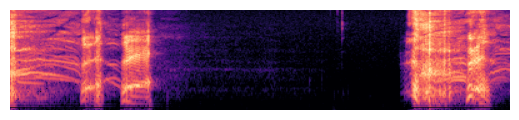

In [53]:
plt.figure(figsize=(5, 1))
img = train_ds[1][0].squeeze().T[:, :400]

plt.imshow(img, origin='lower', aspect='auto', cmap='magma')
plt.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

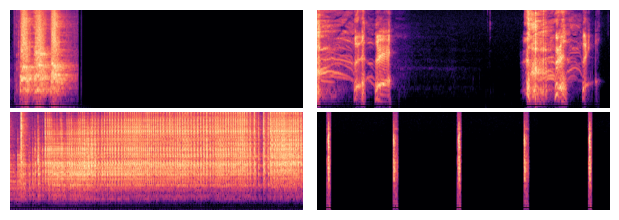

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(6, 2))
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Get sample and crop first 400 time steps as requested
    img = train_ds[i][0].squeeze().T[:, :450]
    
    ax.imshow(img, origin='lower', aspect='auto', cmap='magma')
    ax.axis('off')

# Remove whitespace between subplots and around the edge
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0, right=1, bottom=0, top=1)
plt.savefig(plot_dir / f'spectogram_images.pdf', bbox_inches='tight')
plt.show()